# Presentation SAC Figures

Presentation-oriented variants of selected figures from the 20260528 figure pass. Outputs are written to `/Users/nick/Projects/data/morphseq/results/20260528/sac_figs`.

In [1]:
from pathlib import Path
import sys

import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import numpy as np
import pandas as pd

NOTEBOOK_DIR = Path('/Users/nick/Projects/repositories/morphseq/results/nlammers/20260528')
if str(NOTEBOOK_DIR) not in sys.path:
    sys.path.insert(0, str(NOTEBOOK_DIR))

from figure_utils import CACHE_DIR, TEMP_CMAP, TIMEPOINT_MARKERS, temperature_norm

OUT_DIR = CACHE_DIR / 'sac_figs'
OUT_DIR.mkdir(parents=True, exist_ok=True)

mpl.rcParams.update(
    {
        'font.family': 'Arial',
        'font.sans-serif': ['Arial'],
        'font.size': 15,
        'axes.labelsize': 16.5,
        'xtick.labelsize': 15,
        'ytick.labelsize': 15,
        'legend.fontsize': 12,
        'legend.title_fontsize': 12,
        'text.color': 'black',
        'axes.labelcolor': 'black',
        'xtick.color': 'black',
        'ytick.color': 'black',
        'axes.edgecolor': 'black',
        'axes.grid': False,
        'grid.alpha': 0,
        'pdf.fonttype': 42,
        'ps.fonttype': 42,
        'savefig.facecolor': 'white',
        'savefig.bbox': 'tight',
    }
)

print(OUT_DIR)

/Users/nick/Projects/data/morphseq/results/20260528/sac_figs


In [2]:
joint_all = pd.read_csv(CACHE_DIR / 'joint_141_morph_seq.csv')
joint = joint_all.loc[joint_all['temperature'].astype(float) != 19.0].copy()
stage_group = pd.read_csv(CACHE_DIR / 'seq_vs_morph_stage_group_means_no19C.csv')

# Stage-register each modality to the 28.5C reference cohorts. This is the
# available 28C-like reference in the cached Hotfish data.
reference_temperature = 28.5
reference_timepoints = [24.0, 30.0, 36.0]
reference = joint_all.loc[
    joint_all['temperature'].astype(float).eq(reference_temperature)
    & joint_all['timepoint'].astype(float).isin(reference_timepoints)
].copy()

reference_means = (
    reference.groupby('timepoint', as_index=False)
    .agg(
        morph_stage_mean=('mdl_stage_hpf', 'mean'),
        seq_stage_mean=('pseudostage', 'mean'),
    )
)
reference_means['morph_offset'] = reference_means['morph_stage_mean'] - reference_means['timepoint']
reference_means['seq_offset'] = reference_means['seq_stage_mean'] - reference_means['timepoint']

morph_stage_offset = reference_means['morph_offset'].mean()
seq_stage_offset = reference_means['seq_offset'].mean()

joint_all['mdl_stage_hpf_registered'] = joint_all['mdl_stage_hpf'] - morph_stage_offset
joint_all['pseudostage_registered'] = joint_all['pseudostage'] - seq_stage_offset
joint['mdl_stage_hpf_registered'] = joint['mdl_stage_hpf'] - morph_stage_offset
joint['pseudostage_registered'] = joint['pseudostage'] - seq_stage_offset
stage_group['morph_stage_mean_registered'] = stage_group['morph_stage_mean'] - morph_stage_offset
stage_group['seq_stage_mean_registered'] = stage_group['seq_stage_mean'] - seq_stage_offset

def bootstrap_mean_se(values, rng, n_bootstrap=5000):
    arr = pd.to_numeric(values, errors='coerce').dropna().to_numpy(dtype=float)
    if arr.size < 2:
        return np.nan
    samples = rng.choice(arr, size=(n_bootstrap, arr.size), replace=True)
    return float(np.std(np.mean(samples, axis=1), ddof=1))


rng = np.random.default_rng(20260528)
stage_group_all_rows = []
for (temperature, timepoint), group in joint_all.groupby(['temperature', 'timepoint'], sort=True):
    stage_group_all_rows.append(
        {
            'temperature': temperature,
            'timepoint': timepoint,
            'morph_stage_mean': group['mdl_stage_hpf'].mean(),
            'morph_stage_sd': group['mdl_stage_hpf'].std(ddof=1),
            'morph_stage_mean_boot_se': bootstrap_mean_se(group['mdl_stage_hpf'], rng),
            'seq_stage_mean': group['pseudostage'].mean(),
            'seq_stage_sd': group['pseudostage'].std(ddof=1),
            'seq_stage_mean_boot_se': bootstrap_mean_se(group['pseudostage'], rng),
            'n': group['snip_id'].count(),
        }
    )
stage_group_all = pd.DataFrame(stage_group_all_rows)
stage_group_all['morph_stage_mean_registered'] = stage_group_all['morph_stage_mean'] - morph_stage_offset
stage_group_all['seq_stage_mean_registered'] = stage_group_all['seq_stage_mean'] - seq_stage_offset

print(f'individual embryos: {len(joint)}')
print(f'all-temperature individual embryos: {len(joint_all)}')
print(f'temp x timepoint groups: {len(stage_group)}')
print(f'all-temperature temp x timepoint groups: {len(stage_group_all)}')
print(f'reference temperature: {reference_temperature:g}C')
print(f'morph stage offset: {morph_stage_offset:.3f} hpf')
print(f'seq stage offset: {seq_stage_offset:.3f} hpf')
reference_means

individual embryos: 117
all-temperature individual embryos: 141
temp x timepoint groups: 15
all-temperature temp x timepoint groups: 18
reference temperature: 28.5C
morph stage offset: -0.368 hpf
seq stage offset: 1.438 hpf


,timepoint,morph_stage_mean,seq_stage_mean,morph_offset,seq_offset
0,24.0,24.761971,26.304693,0.761971,2.304693
1,30.0,29.910695,31.478885,-0.089305,1.478885
2,36.0,34.222927,36.530674,-1.777073,0.530674


In [3]:
def marker_for_timepoint(timepoint):
    return TIMEPOINT_MARKERS.get(float(timepoint), 'o')


def add_timepoint_legend(ax, timepoints):
    handles = []
    for timepoint in sorted(pd.Series(timepoints).dropna().unique(), key=float):
        handles.append(
            Line2D(
                [0],
                [0],
                marker=marker_for_timepoint(timepoint),
                linestyle='none',
                markerfacecolor='white',
                markeredgecolor='black',
                markeredgewidth=1.2,
                markersize=7.5,
                label=f'{float(timepoint):g} hpf',
            )
        )
    return ax.legend(handles=handles, title='collection', frameon=False, loc='best')


def scatter_by_timepoint(ax, data, x, y, *, size, alpha, linewidth, zorder):
    cmap = plt.get_cmap(TEMP_CMAP)
    norm = temperature_norm()
    for timepoint, group in data.groupby('timepoint', sort=True):
        ax.scatter(
            group[x],
            group[y],
            c=group['temperature'],
            cmap=cmap,
            norm=norm,
            marker=marker_for_timepoint(timepoint),
            s=size,
            alpha=alpha,
            edgecolor='black',
            linewidth=linewidth,
            rasterized=True,
            zorder=zorder,
        )
    mappable = mpl.cm.ScalarMappable(norm=norm, cmap=cmap)
    mappable.set_array([])
    return mappable


def add_black_arrow_axes(ax, *, linewidth=2.3):
    for spine in ax.spines.values():
        spine.set_visible(False)
    ax.grid(False)
    ax.tick_params(
        axis='both',
        which='major',
        direction='out',
        length=6.5,
        width=1.8,
        colors='black',
        bottom=True,
        left=True,
        top=False,
        right=False,
    )
    arrowprops = dict(
        arrowstyle='-|>',
        color='black',
        linewidth=linewidth,
        mutation_scale=17,
        shrinkA=0,
        shrinkB=0,
    )
    ax.annotate('', xy=(1.025, 0), xytext=(0, 0), xycoords='axes fraction', arrowprops=arrowprops, annotation_clip=False)
    ax.annotate('', xy=(0, 1.025), xytext=(0, 0), xycoords='axes fraction', arrowprops=arrowprops, annotation_clip=False)


def add_identity(ax):
    lo = min(ax.get_xlim()[0], ax.get_ylim()[0])
    hi = max(ax.get_xlim()[1], ax.get_ylim()[1])
    ax.plot([lo, hi], [lo, hi], color='black', linestyle='--', linewidth=2.0, zorder=2)

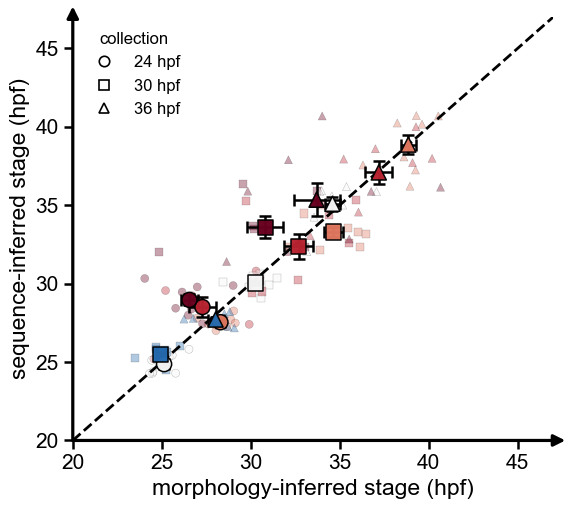

In [4]:
fig, ax = plt.subplots(figsize=(6.2, 5.5))

scatter_by_timepoint(
    ax,
    joint,
    'mdl_stage_hpf_registered',
    'pseudostage_registered',
    size=34,
    alpha=0.36,
    linewidth=0.25,
    zorder=1,
)

ax.errorbar(
    stage_group['morph_stage_mean_registered'],
    stage_group['seq_stage_mean_registered'],
    xerr=stage_group['morph_stage_mean_boot_se'],
    yerr=stage_group['seq_stage_mean_boot_se'],
    fmt='none',
    ecolor='black',
    elinewidth=1.8,
    capsize=4,
    capthick=1.8,
    alpha=1,
    zorder=3,
)

scatter_by_timepoint(
    ax,
    stage_group,
    'morph_stage_mean_registered',
    'seq_stage_mean_registered',
    size=118,
    alpha=0.98,
    linewidth=1.1,
    zorder=4,
)

ax.set_xlim(20, 47)
ax.set_ylim(20, 47)
add_identity(ax)
ax.set_xlabel('morphology-inferred stage (hpf)')
ax.set_ylabel('sequence-inferred stage (hpf)')
add_black_arrow_axes(ax)

legend = add_timepoint_legend(ax, stage_group['timepoint'])
for text in legend.get_texts():
    text.set_color('black')
legend.get_title().set_color('black')

for suffix in ('png', 'pdf'):
    fig.savefig(OUT_DIR / f'01a_seq_vs_morph_stage_individuals_and_group_means_min20_axes_sac.{suffix}', dpi=300)

plt.show()

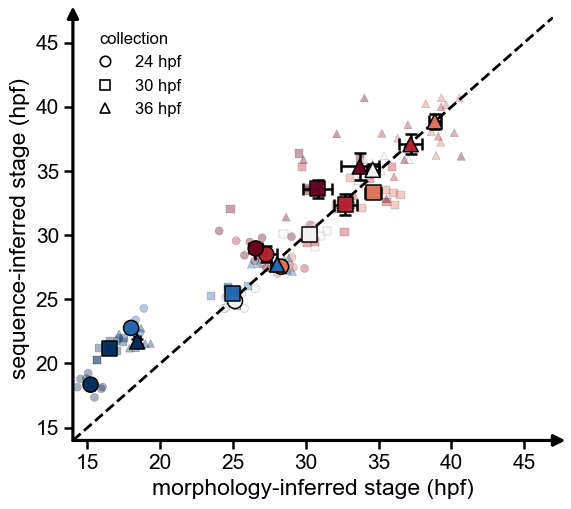

In [5]:
fig, ax = plt.subplots(figsize=(6.2, 5.5))

scatter_by_timepoint(
    ax,
    joint_all,
    'mdl_stage_hpf_registered',
    'pseudostage_registered',
    size=34,
    alpha=0.36,
    linewidth=0.25,
    zorder=1,
)

ax.errorbar(
    stage_group_all['morph_stage_mean_registered'],
    stage_group_all['seq_stage_mean_registered'],
    xerr=stage_group_all['morph_stage_mean_boot_se'],
    yerr=stage_group_all['seq_stage_mean_boot_se'],
    fmt='none',
    ecolor='black',
    elinewidth=1.8,
    capsize=4,
    capthick=1.8,
    alpha=1,
    zorder=3,
)

scatter_by_timepoint(
    ax,
    stage_group_all,
    'morph_stage_mean_registered',
    'seq_stage_mean_registered',
    size=118,
    alpha=0.98,
    linewidth=1.1,
    zorder=4,
)

ax.set_xlim(14, 47)
ax.set_ylim(14, 47)
add_identity(ax)
ax.set_xlabel('morphology-inferred stage (hpf)')
ax.set_ylabel('sequence-inferred stage (hpf)')
add_black_arrow_axes(ax)

legend = add_timepoint_legend(ax, stage_group_all['timepoint'])
for text in legend.get_texts():
    text.set_color('black')
legend.get_title().set_color('black')

for suffix in ('png', 'pdf'):
    fig.savefig(OUT_DIR / f'01a_seq_vs_morph_stage_individuals_and_group_means_registered_all_temps_axes14_47_sac.{suffix}', dpi=300)

plt.show()

## Staging variability comparison

Presentation-formatted versions of `01b_staging_variability_comparison_bootstrap_se`, with and without 19C plus the 25C 24 hpf cohort.

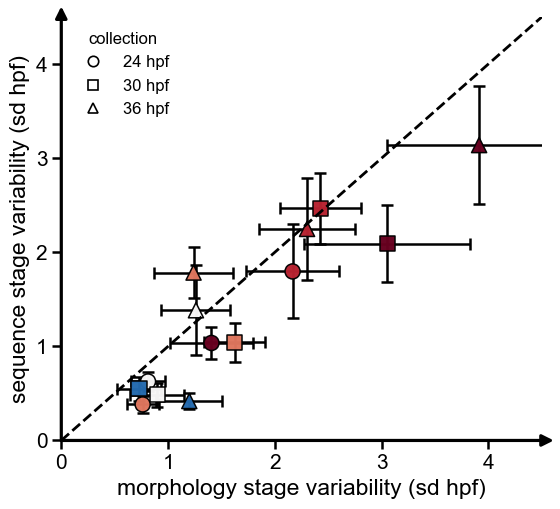

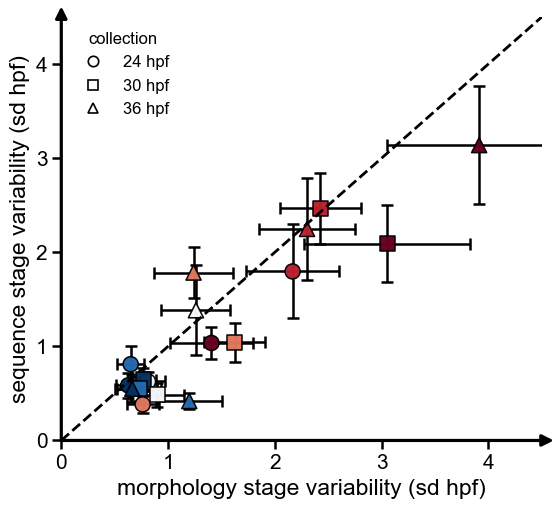

all cohorts: 18
without 19C and 25C 24 hpf: 14


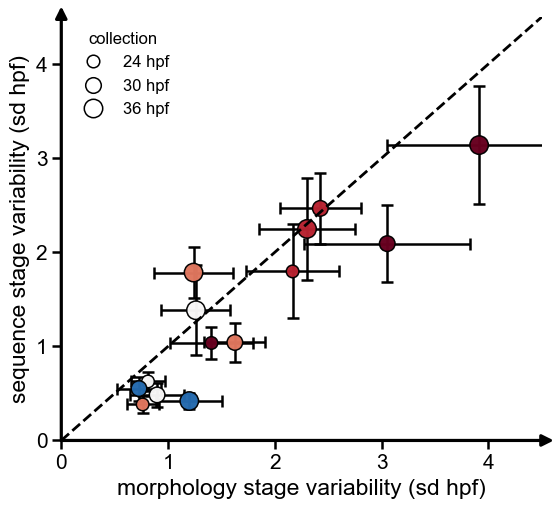

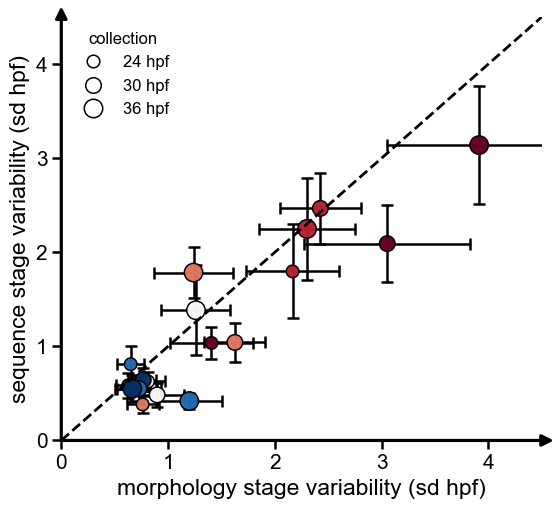

In [6]:
cohort_boot_all = pd.read_csv(CACHE_DIR / 'tempo_noise_cohort_summary_bootstrap_se.csv')
cohort_boot_without_19c_25c24 = cohort_boot_all.loc[
    ~(
        np.isclose(cohort_boot_all['temperature'], 19.0)
        | (
            np.isclose(cohort_boot_all['temperature'], 25.0)
            & np.isclose(cohort_boot_all['timepoint'], 24.0)
        )
    ),
    :,
].copy()


def plot_staging_variability_presentation(data, output_stem, *, axis_max=4.5):
    fig, ax = plt.subplots(figsize=(6.2, 5.5))

    ax.errorbar(
        data['morph_stage_std'],
        data['seq_stage_std'],
        xerr=data['morph_stage_std_boot_se'],
        yerr=data['seq_stage_std_boot_se'],
        fmt='none',
        ecolor='black',
        elinewidth=1.8,
        capsize=4,
        capthick=1.8,
        alpha=1,
        zorder=1,
    )

    scatter_by_timepoint(
        ax,
        data,
        'morph_stage_std',
        'seq_stage_std',
        size=118,
        alpha=0.98,
        linewidth=1.1,
        zorder=2,
    )

    ax.set_xlim(0, axis_max)
    ax.set_ylim(0, axis_max)
    ax.set_xticks(np.arange(0, axis_max, 1))
    ax.set_yticks(np.arange(0, axis_max, 1))
    add_identity(ax)
    ax.set_xlabel('morphology stage variability (sd hpf)')
    ax.set_ylabel('sequence stage variability (sd hpf)')
    add_black_arrow_axes(ax)

    legend = add_timepoint_legend(ax, data['timepoint'])
    for text in legend.get_texts():
        text.set_color('black')
    legend.get_title().set_color('black')

    for suffix in ('png', 'pdf'):
        fig.savefig(OUT_DIR / f'{output_stem}.{suffix}', dpi=300)

    return fig, ax


fig, ax = plot_staging_variability_presentation(
    cohort_boot_without_19c_25c24,
    '01b_staging_variability_comparison_bootstrap_se_without_19C_25C24_sac',
)
plt.show()

fig, ax = plot_staging_variability_presentation(
    cohort_boot_all,
    '01b_staging_variability_comparison_bootstrap_se_with_19C_25C24_sac',
)
plt.show()

print(f'all cohorts: {len(cohort_boot_all)}')
print(f'without 19C and 25C 24 hpf: {len(cohort_boot_without_19c_25c24)}')


STAGING_VARIABILITY_SIZE_BY_COLLECTION = {24.0: 82, 30.0: 126, 36.0: 176}


def plot_staging_variability_presentation_size_by_collection(data, output_stem, *, axis_max=4.5):
    fig, ax = plt.subplots(figsize=(6.2, 5.5))

    ax.errorbar(
        data['morph_stage_std'],
        data['seq_stage_std'],
        xerr=data['morph_stage_std_boot_se'],
        yerr=data['seq_stage_std_boot_se'],
        fmt='none',
        ecolor='black',
        elinewidth=1.8,
        capsize=4,
        capthick=1.8,
        alpha=1,
        zorder=1,
    )

    cmap = plt.get_cmap(TEMP_CMAP)
    norm = temperature_norm()
    for timepoint, group in data.groupby('timepoint', sort=True):
        ax.scatter(
            group['morph_stage_std'],
            group['seq_stage_std'],
            c=group['temperature'],
            cmap=cmap,
            norm=norm,
            marker='o',
            s=STAGING_VARIABILITY_SIZE_BY_COLLECTION.get(float(timepoint), 126),
            alpha=0.98,
            edgecolor='black',
            linewidth=1.1,
            zorder=2,
        )

    ax.set_xlim(0, axis_max)
    ax.set_ylim(0, axis_max)
    ax.set_xticks(np.arange(0, axis_max, 1))
    ax.set_yticks(np.arange(0, axis_max, 1))
    add_identity(ax)
    ax.set_xlabel('morphology stage variability (sd hpf)')
    ax.set_ylabel('sequence stage variability (sd hpf)')
    add_black_arrow_axes(ax)

    legend_handles = []
    for timepoint in sorted(data['timepoint'].unique()):
        legend_handles.append(
            Line2D(
                [0],
                [0],
                marker='o',
                linestyle='none',
                markerfacecolor='white',
                markeredgecolor='black',
                markeredgewidth=1.1,
                markersize=np.sqrt(STAGING_VARIABILITY_SIZE_BY_COLLECTION.get(float(timepoint), 126)),
                label=f'{float(timepoint):g} hpf',
            )
        )
    legend = ax.legend(handles=legend_handles, title='collection', frameon=False, loc='best')
    for text in [legend.get_title(), *legend.get_texts()]:
        text.set_color('black')

    for suffix in ('png', 'pdf'):
        fig.savefig(OUT_DIR / f'{output_stem}.{suffix}', dpi=300)

    return fig, ax


fig, ax = plot_staging_variability_presentation_size_by_collection(
    cohort_boot_without_19c_25c24,
    '01b_staging_variability_comparison_bootstrap_se_without_19C_25C24_marker_size_by_collection_sac',
)
plt.show()

fig, ax = plot_staging_variability_presentation_size_by_collection(
    cohort_boot_all,
    '01b_staging_variability_comparison_bootstrap_se_with_19C_25C24_marker_size_by_collection_sac',
)
plt.show()


In [ ]:
STAGE_VARIABILITY_TEMP_AVG_N_BOOTSTRAP = 5000
STAGE_VARIABILITY_TEMP_AVG_SEED = 20260528
STAGE_VARIABILITY_TEMP_AVG_AXIS_LIMITS = (0, 4.5)
STAGE_VARIABILITY_TEMP_AVG_OUTPUT_STEMS = {
    'morphology': '01c_morph_stage_variability_vs_temperature_collection_average_bootstrap_se_with_19C_25C24_sac',
    'transcription': '01c_transcription_stage_variability_vs_temperature_collection_average_bootstrap_se_with_19C_25C24_sac',
}
STAGE_VARIABILITY_TEMP_AVG_COMBINED_OUTPUT_STEM = '01c_stage_variability_vs_temperature_collection_average_bootstrap_se_with_19C_25C24_sac'
STAGE_VARIABILITY_TEMP_AVG_TABLE_PATH = OUT_DIR / '01c_stage_variability_vs_temperature_collection_average_bootstrap_se_with_19C_25C24_sac.csv'


def bootstrap_collection_average_stage_variability(
    data,
    value_col,
    *,
    n_bootstrap=STAGE_VARIABILITY_TEMP_AVG_N_BOOTSTRAP,
    seed=STAGE_VARIABILITY_TEMP_AVG_SEED,
):
    rng = np.random.default_rng(seed)
    rows = []
    working = data.copy()
    working['temperature'] = working['temperature'].astype(float)
    working['timepoint'] = working['timepoint'].astype(float)

    for temperature, temp_data in working.groupby('temperature', sort=True):
        cohort_arrays = []
        for _, cohort in temp_data.groupby('timepoint', sort=True):
            values = pd.to_numeric(cohort[value_col], errors='coerce').dropna().to_numpy(dtype=float)
            if values.size >= 2:
                cohort_arrays.append(values)
        if not cohort_arrays:
            continue

        observed = np.array([np.std(values, ddof=1) for values in cohort_arrays], dtype=float)
        boot = np.empty(n_bootstrap, dtype=float)
        for boot_index in range(n_bootstrap):
            boot[boot_index] = np.mean(
                [
                    np.std(rng.choice(values, size=values.size, replace=True), ddof=1)
                    for values in cohort_arrays
                ]
            )

        rows.append(
            {
                'temperature': float(temperature),
                'temperature_plot': 34.0 if np.isclose(float(temperature), 33.5) else float(temperature),
                'stage_variability_mean': float(np.mean(observed)),
                'stage_variability_boot_se': float(np.std(boot, ddof=1)),
                'n_collection_cohorts': len(cohort_arrays),
                'n_embryos': int(sum(values.size for values in cohort_arrays)),
                'n_bootstrap': n_bootstrap,
                'bootstrap_seed': seed,
            }
        )

    return pd.DataFrame(rows).sort_values('temperature').reset_index(drop=True)


stage_variability_temp_avg_tables = []
for modality, value_col, seed_offset in (
    ('morphology', 'mdl_stage_hpf', 0),
    ('transcription', 'pseudostage', 1),
):
    summary = bootstrap_collection_average_stage_variability(
        joint_all,
        value_col,
        seed=STAGE_VARIABILITY_TEMP_AVG_SEED + seed_offset,
    )
    summary.insert(0, 'modality', modality)
    stage_variability_temp_avg_tables.append(summary)

stage_variability_temp_avg = pd.concat(stage_variability_temp_avg_tables, ignore_index=True)
stage_variability_temp_avg.to_csv(STAGE_VARIABILITY_TEMP_AVG_TABLE_PATH, index=False)


def style_stage_variability_temperature_axes(ax):
    x_ticks = np.array([19.0, 25.0, 28.5, 32.0, 34.0, 35.0])
    ax.set_xlim(18.0, 36.2)
    ax.set_ylim(*STAGE_VARIABILITY_TEMP_AVG_AXIS_LIMITS)
    ax.set_xticks(x_ticks)
    ax.set_xticklabels([f'{temp:g}' for temp in x_ticks])
    ax.set_yticks(np.arange(0, STAGE_VARIABILITY_TEMP_AVG_AXIS_LIMITS[1] + 0.1, 1))
    ax.set_xlabel('temperature (C)')
    ax.set_ylabel('stage variability (sd hpf)')
    add_black_arrow_axes(ax)


def plot_stage_variability_vs_temperature_collection_average(summary, output_stem):
    fig, ax = plt.subplots(figsize=(6.2, 5.5))
    cmap = plt.get_cmap(TEMP_CMAP)
    norm = temperature_norm()

    ax.plot(
        summary['temperature_plot'],
        summary['stage_variability_mean'],
        color='black',
        linewidth=1.55,
        zorder=1,
    )
    ax.errorbar(
        summary['temperature_plot'],
        summary['stage_variability_mean'],
        yerr=summary['stage_variability_boot_se'],
        fmt='none',
        ecolor='black',
        elinewidth=1.8,
        capsize=4,
        capthick=1.8,
        alpha=1,
        zorder=2,
    )
    ax.scatter(
        summary['temperature_plot'],
        summary['stage_variability_mean'],
        c=summary['temperature'],
        cmap=cmap,
        norm=norm,
        marker='o',
        s=126,
        alpha=0.98,
        edgecolor='black',
        linewidth=1.1,
        zorder=3,
    )

    style_stage_variability_temperature_axes(ax)
    fig.tight_layout()
    for suffix in ('png', 'pdf'):
        fig.savefig(OUT_DIR / f'{output_stem}.{suffix}', dpi=300, bbox_inches='tight')
    plt.close(fig)


def plot_combined_stage_variability_vs_temperature(stage_variability_temp_avg):
    fig, axes = plt.subplots(1, 2, figsize=(11.8, 5.5), sharey=True)
    for ax, modality in zip(axes, ('morphology', 'transcription')):
        summary = stage_variability_temp_avg.loc[stage_variability_temp_avg['modality'].eq(modality)].copy()
        cmap = plt.get_cmap(TEMP_CMAP)
        norm = temperature_norm()
        ax.plot(
            summary['temperature_plot'],
            summary['stage_variability_mean'],
            color='black',
            linewidth=1.55,
            zorder=1,
        )
        ax.errorbar(
            summary['temperature_plot'],
            summary['stage_variability_mean'],
            yerr=summary['stage_variability_boot_se'],
            fmt='none',
            ecolor='black',
            elinewidth=1.8,
            capsize=4,
            capthick=1.8,
            alpha=1,
            zorder=2,
        )
        ax.scatter(
            summary['temperature_plot'],
            summary['stage_variability_mean'],
            c=summary['temperature'],
            cmap=cmap,
            norm=norm,
            marker='o',
            s=126,
            alpha=0.98,
            edgecolor='black',
            linewidth=1.1,
            zorder=3,
        )
        style_stage_variability_temperature_axes(ax)
        if modality == 'transcription':
            ax.set_ylabel('')
        ax.text(
            0.04,
            0.94,
            modality,
            transform=ax.transAxes,
            ha='left',
            va='top',
            color='black',
        )
    fig.tight_layout()
    for suffix in ('png', 'pdf'):
        fig.savefig(OUT_DIR / f'{STAGE_VARIABILITY_TEMP_AVG_COMBINED_OUTPUT_STEM}.{suffix}', dpi=300, bbox_inches='tight')
    plt.close(fig)


for modality, output_stem in STAGE_VARIABILITY_TEMP_AVG_OUTPUT_STEMS.items():
    modality_summary = stage_variability_temp_avg.loc[stage_variability_temp_avg['modality'].eq(modality)].copy()
    plot_stage_variability_vs_temperature_collection_average(modality_summary, output_stem)

plot_combined_stage_variability_vs_temperature(stage_variability_temp_avg)

print(f'Saved table {STAGE_VARIABILITY_TEMP_AVG_TABLE_PATH}')
for modality, output_stem in STAGE_VARIABILITY_TEMP_AVG_OUTPUT_STEMS.items():
    print(f'Saved {OUT_DIR / f"{output_stem}.png"}')
    print(f'Saved {OUT_DIR / f"{output_stem}.pdf"}')
print(f'Saved {OUT_DIR / f"{STAGE_VARIABILITY_TEMP_AVG_COMBINED_OUTPUT_STEM}.png"}')
print(f'Saved {OUT_DIR / f"{STAGE_VARIABILITY_TEMP_AVG_COMBINED_OUTPUT_STEM}.pdf"}')
stage_variability_temp_avg


In [ ]:
STAGE_VARIABILITY_BY_COLLECTION_AXIS_LIMITS = (0, 4.5)
STAGE_VARIABILITY_BY_COLLECTION_TABLE_PATH = OUT_DIR / '01c_stage_variability_vs_temperature_by_collection_bootstrap_se_with_19C_25C24_sac.csv'

stage_variability_by_collection = pd.read_csv(CACHE_DIR / 'tempo_noise_cohort_summary_bootstrap_se.csv')
stage_variability_by_collection['temperature'] = stage_variability_by_collection['temperature'].astype(float)
stage_variability_by_collection['temperature_plot'] = stage_variability_by_collection['temperature'].where(
    ~np.isclose(stage_variability_by_collection['temperature'], 33.5),
    34.0,
)
stage_variability_by_collection['timepoint'] = stage_variability_by_collection['timepoint'].astype(float)

stage_variability_by_collection_long = []
for modality, value_col, se_col in (
    ('morphology', 'morph_stage_std', 'morph_stage_std_boot_se'),
    ('transcription', 'seq_stage_std', 'seq_stage_std_boot_se'),
):
    modality_table = stage_variability_by_collection[
        ['temperature', 'temperature_plot', 'timepoint', value_col, se_col, 'n', 'n_bootstrap', 'bootstrap_seed']
    ].copy()
    modality_table = modality_table.rename(
        columns={
            value_col: 'stage_variability',
            se_col: 'stage_variability_boot_se',
        }
    )
    modality_table.insert(0, 'modality', modality)
    stage_variability_by_collection_long.append(modality_table)

stage_variability_by_collection_long = pd.concat(stage_variability_by_collection_long, ignore_index=True)
stage_variability_by_collection_long.to_csv(STAGE_VARIABILITY_BY_COLLECTION_TABLE_PATH, index=False)


def style_stage_variability_by_collection_axes(ax):
    x_ticks = np.array([19.0, 25.0, 28.5, 32.0, 34.0, 35.0])
    ax.set_xlim(18.0, 36.2)
    ax.set_ylim(*STAGE_VARIABILITY_BY_COLLECTION_AXIS_LIMITS)
    ax.set_xticks(x_ticks)
    ax.set_xticklabels([f'{temp:g}' for temp in x_ticks])
    ax.set_yticks(np.arange(0, STAGE_VARIABILITY_BY_COLLECTION_AXIS_LIMITS[1] + 0.1, 1))
    ax.set_xlabel('temperature (C)')
    ax.set_ylabel('stage variability (sd hpf)')
    add_black_arrow_axes(ax)


def plot_stage_variability_collection_modality(summary, output_stem, *, label_text=None):
    fig, ax = plt.subplots(figsize=(6.2, 5.5))
    cmap = plt.get_cmap(TEMP_CMAP)
    norm = temperature_norm()

    ax.plot(
        summary['temperature_plot'],
        summary['stage_variability'],
        color='black',
        linewidth=1.55,
        zorder=1,
    )
    ax.errorbar(
        summary['temperature_plot'],
        summary['stage_variability'],
        yerr=summary['stage_variability_boot_se'],
        fmt='none',
        ecolor='black',
        elinewidth=1.8,
        capsize=4,
        capthick=1.8,
        alpha=1,
        zorder=2,
    )
    ax.scatter(
        summary['temperature_plot'],
        summary['stage_variability'],
        c=summary['temperature'],
        cmap=cmap,
        norm=norm,
        marker='o',
        s=126,
        alpha=0.98,
        edgecolor='black',
        linewidth=1.1,
        zorder=3,
    )

    style_stage_variability_by_collection_axes(ax)
    if label_text is not None:
        ax.text(
            0.04,
            0.94,
            label_text,
            transform=ax.transAxes,
            ha='left',
            va='top',
            color='black',
        )
    fig.tight_layout()
    for suffix in ('png', 'pdf'):
        fig.savefig(OUT_DIR / f'{output_stem}.{suffix}', dpi=300, bbox_inches='tight')
    plt.close(fig)


def plot_stage_variability_collection_combined(collection_data, output_stem, *, timepoint):
    fig, axes = plt.subplots(1, 2, figsize=(11.8, 5.5), sharey=True)
    for ax, modality in zip(axes, ('morphology', 'transcription')):
        summary = collection_data.loc[collection_data['modality'].eq(modality)].copy()
        cmap = plt.get_cmap(TEMP_CMAP)
        norm = temperature_norm()
        ax.plot(
            summary['temperature_plot'],
            summary['stage_variability'],
            color='black',
            linewidth=1.55,
            zorder=1,
        )
        ax.errorbar(
            summary['temperature_plot'],
            summary['stage_variability'],
            yerr=summary['stage_variability_boot_se'],
            fmt='none',
            ecolor='black',
            elinewidth=1.8,
            capsize=4,
            capthick=1.8,
            alpha=1,
            zorder=2,
        )
        ax.scatter(
            summary['temperature_plot'],
            summary['stage_variability'],
            c=summary['temperature'],
            cmap=cmap,
            norm=norm,
            marker='o',
            s=126,
            alpha=0.98,
            edgecolor='black',
            linewidth=1.1,
            zorder=3,
        )
        style_stage_variability_by_collection_axes(ax)
        if modality == 'transcription':
            ax.set_ylabel('')
        ax.text(
            0.04,
            0.94,
            f'{modality} / {timepoint:g} hpf',
            transform=ax.transAxes,
            ha='left',
            va='top',
            color='black',
        )
    fig.tight_layout()
    for suffix in ('png', 'pdf'):
        fig.savefig(OUT_DIR / f'{output_stem}.{suffix}', dpi=300, bbox_inches='tight')
    plt.close(fig)


stage_variability_by_collection_outputs = []
for timepoint in sorted(stage_variability_by_collection_long['timepoint'].unique()):
    collection_data = stage_variability_by_collection_long.loc[
        np.isclose(stage_variability_by_collection_long['timepoint'], timepoint)
    ].copy()
    time_label = f'{int(timepoint):02d}hpf'

    for modality in ('morphology', 'transcription'):
        modality_data = collection_data.loc[collection_data['modality'].eq(modality)].copy()
        modality_stem = 'morph' if modality == 'morphology' else 'transcription'
        output_stem = f'01c_{modality_stem}_stage_variability_vs_temperature_{time_label}_collection_bootstrap_se_with_19C_25C24_sac'
        plot_stage_variability_collection_modality(
            modality_data,
            output_stem,
            label_text=f'{modality} / {timepoint:g} hpf',
        )
        stage_variability_by_collection_outputs.append(output_stem)

    combined_output_stem = f'01c_stage_variability_vs_temperature_{time_label}_collection_bootstrap_se_with_19C_25C24_sac'
    plot_stage_variability_collection_combined(collection_data, combined_output_stem, timepoint=timepoint)
    stage_variability_by_collection_outputs.append(combined_output_stem)

print(f'Saved table {STAGE_VARIABILITY_BY_COLLECTION_TABLE_PATH}')
for output_stem in stage_variability_by_collection_outputs:
    print(f'Saved {OUT_DIR / f"{output_stem}.png"}')
    print(f'Saved {OUT_DIR / f"{output_stem}.pdf"}')
stage_variability_by_collection_long


In [ ]:
STAGE_VARIABILITY_NO19C_N_BOOTSTRAP = 5000
STAGE_VARIABILITY_NO19C_SEED = 20260528
STAGE_VARIABILITY_NO19C_AXIS_LIMITS = (0, 4.5)
STAGE_VARIABILITY_NO19C_AVG_TABLE_PATH = OUT_DIR / '01c_stage_variability_vs_temperature_collection_average_bootstrap_se_no19C_with_25C24_sac.csv'
STAGE_VARIABILITY_NO19C_BY_COLLECTION_TABLE_PATH = OUT_DIR / '01c_stage_variability_vs_temperature_by_collection_bootstrap_se_no19C_with_25C24_sac.csv'
STAGE_VARIABILITY_NO19C_AVG_OUTPUT_STEMS = {
    'morphology': '01c_morph_stage_variability_vs_temperature_collection_average_bootstrap_se_no19C_with_25C24_sac',
    'transcription': '01c_transcription_stage_variability_vs_temperature_collection_average_bootstrap_se_no19C_with_25C24_sac',
}
STAGE_VARIABILITY_NO19C_AVG_COMBINED_OUTPUT_STEM = '01c_stage_variability_vs_temperature_collection_average_bootstrap_se_no19C_with_25C24_sac'
STAGE_VARIABILITY_NO19C_AVG_OVERLAY_OUTPUT_STEM = '01c_morph_transcription_stage_variability_vs_temperature_collection_average_overlay_bootstrap_se_no19C_with_25C24_sac'


def bootstrap_collection_average_stage_variability_no19c(
    data,
    value_col,
    *,
    n_bootstrap=STAGE_VARIABILITY_NO19C_N_BOOTSTRAP,
    seed=STAGE_VARIABILITY_NO19C_SEED,
):
    rng = np.random.default_rng(seed)
    rows = []
    working = data.copy()
    working['temperature'] = working['temperature'].astype(float)
    working['timepoint'] = working['timepoint'].astype(float)
    working = working.loc[~np.isclose(working['temperature'], 19.0)].copy()

    for temperature, temp_data in working.groupby('temperature', sort=True):
        cohort_arrays = []
        for _, cohort in temp_data.groupby('timepoint', sort=True):
            values = pd.to_numeric(cohort[value_col], errors='coerce').dropna().to_numpy(dtype=float)
            if values.size >= 2:
                cohort_arrays.append(values)
        if not cohort_arrays:
            continue

        observed = np.array([np.std(values, ddof=1) for values in cohort_arrays], dtype=float)
        boot = np.empty(n_bootstrap, dtype=float)
        for boot_index in range(n_bootstrap):
            boot[boot_index] = np.mean(
                [
                    np.std(rng.choice(values, size=values.size, replace=True), ddof=1)
                    for values in cohort_arrays
                ]
            )

        rows.append(
            {
                'temperature': float(temperature),
                'temperature_plot': 34.0 if np.isclose(float(temperature), 33.5) else float(temperature),
                'stage_variability_mean': float(np.mean(observed)),
                'stage_variability_boot_se': float(np.std(boot, ddof=1)),
                'n_collection_cohorts': len(cohort_arrays),
                'n_embryos': int(sum(values.size for values in cohort_arrays)),
                'n_bootstrap': n_bootstrap,
                'bootstrap_seed': seed,
            }
        )

    return pd.DataFrame(rows).sort_values('temperature').reset_index(drop=True)


stage_variability_no19c_avg_tables = []
for modality, value_col, seed_offset in (
    ('morphology', 'mdl_stage_hpf', 0),
    ('transcription', 'pseudostage', 1),
):
    summary = bootstrap_collection_average_stage_variability_no19c(
        joint_all,
        value_col,
        seed=STAGE_VARIABILITY_NO19C_SEED + seed_offset,
    )
    summary.insert(0, 'modality', modality)
    stage_variability_no19c_avg_tables.append(summary)

stage_variability_no19c_avg = pd.concat(stage_variability_no19c_avg_tables, ignore_index=True)
stage_variability_no19c_avg.to_csv(STAGE_VARIABILITY_NO19C_AVG_TABLE_PATH, index=False)

stage_variability_no19c_by_collection = pd.read_csv(CACHE_DIR / 'tempo_noise_cohort_summary_bootstrap_se.csv')
stage_variability_no19c_by_collection['temperature'] = stage_variability_no19c_by_collection['temperature'].astype(float)
stage_variability_no19c_by_collection = stage_variability_no19c_by_collection.loc[
    ~np.isclose(stage_variability_no19c_by_collection['temperature'], 19.0)
].copy()
stage_variability_no19c_by_collection['temperature_plot'] = stage_variability_no19c_by_collection['temperature'].where(
    ~np.isclose(stage_variability_no19c_by_collection['temperature'], 33.5),
    34.0,
)
stage_variability_no19c_by_collection['timepoint'] = stage_variability_no19c_by_collection['timepoint'].astype(float)

stage_variability_no19c_by_collection_long = []
for modality, value_col, se_col in (
    ('morphology', 'morph_stage_std', 'morph_stage_std_boot_se'),
    ('transcription', 'seq_stage_std', 'seq_stage_std_boot_se'),
):
    modality_table = stage_variability_no19c_by_collection[
        ['temperature', 'temperature_plot', 'timepoint', value_col, se_col, 'n', 'n_bootstrap', 'bootstrap_seed']
    ].copy()
    modality_table = modality_table.rename(
        columns={
            value_col: 'stage_variability',
            se_col: 'stage_variability_boot_se',
        }
    )
    modality_table.insert(0, 'modality', modality)
    stage_variability_no19c_by_collection_long.append(modality_table)

stage_variability_no19c_by_collection_long = pd.concat(stage_variability_no19c_by_collection_long, ignore_index=True)
stage_variability_no19c_by_collection_long.to_csv(STAGE_VARIABILITY_NO19C_BY_COLLECTION_TABLE_PATH, index=False)


def style_stage_variability_no19c_axes(ax):
    x_ticks = np.array([25.0, 28.5, 32.0, 34.0, 35.0])
    ax.set_xlim(24.0, 36.2)
    ax.set_ylim(*STAGE_VARIABILITY_NO19C_AXIS_LIMITS)
    ax.set_xticks(x_ticks)
    ax.set_xticklabels([f'{temp:g}' for temp in x_ticks])
    ax.set_yticks(np.arange(0, STAGE_VARIABILITY_NO19C_AXIS_LIMITS[1] + 0.1, 1))
    ax.set_xlabel('temperature (C)')
    ax.set_ylabel('stage variability (sd hpf)')
    add_black_arrow_axes(ax)


def plot_stage_variability_no19c_single(summary, output_stem, *, y_col='stage_variability_mean', se_col='stage_variability_boot_se', label_text=None):
    fig, ax = plt.subplots(figsize=(6.2, 5.5))
    cmap = plt.get_cmap(TEMP_CMAP)
    norm = temperature_norm()

    ax.plot(
        summary['temperature_plot'],
        summary[y_col],
        color='black',
        linewidth=1.55,
        zorder=1,
    )
    ax.errorbar(
        summary['temperature_plot'],
        summary[y_col],
        yerr=summary[se_col],
        fmt='none',
        ecolor='black',
        elinewidth=1.8,
        capsize=4,
        capthick=1.8,
        alpha=1,
        zorder=2,
    )
    ax.scatter(
        summary['temperature_plot'],
        summary[y_col],
        c=summary['temperature'],
        cmap=cmap,
        norm=norm,
        marker='o',
        s=126,
        alpha=0.98,
        edgecolor='black',
        linewidth=1.1,
        zorder=3,
    )

    style_stage_variability_no19c_axes(ax)
    if label_text is not None:
        ax.text(0.04, 0.94, label_text, transform=ax.transAxes, ha='left', va='top', color='black')
    fig.tight_layout()
    for suffix in ('png', 'pdf'):
        fig.savefig(OUT_DIR / f'{output_stem}.{suffix}', dpi=300, bbox_inches='tight')
    plt.close(fig)


def plot_stage_variability_no19c_two_panel(data, output_stem, *, y_col, se_col, timepoint=None):
    fig, axes = plt.subplots(1, 2, figsize=(11.8, 5.5), sharey=True)
    for ax, modality in zip(axes, ('morphology', 'transcription')):
        summary = data.loc[data['modality'].eq(modality)].copy()
        cmap = plt.get_cmap(TEMP_CMAP)
        norm = temperature_norm()
        ax.plot(summary['temperature_plot'], summary[y_col], color='black', linewidth=1.55, zorder=1)
        ax.errorbar(
            summary['temperature_plot'],
            summary[y_col],
            yerr=summary[se_col],
            fmt='none',
            ecolor='black',
            elinewidth=1.8,
            capsize=4,
            capthick=1.8,
            alpha=1,
            zorder=2,
        )
        ax.scatter(
            summary['temperature_plot'],
            summary[y_col],
            c=summary['temperature'],
            cmap=cmap,
            norm=norm,
            marker='o',
            s=126,
            alpha=0.98,
            edgecolor='black',
            linewidth=1.1,
            zorder=3,
        )
        style_stage_variability_no19c_axes(ax)
        if modality == 'transcription':
            ax.set_ylabel('')
        label = modality if timepoint is None else f'{modality} / {timepoint:g} hpf'
        ax.text(0.04, 0.94, label, transform=ax.transAxes, ha='left', va='top', color='black')
    fig.tight_layout()
    for suffix in ('png', 'pdf'):
        fig.savefig(OUT_DIR / f'{output_stem}.{suffix}', dpi=300, bbox_inches='tight')
    plt.close(fig)


def plot_stage_variability_no19c_average_overlay(data):
    fig, ax = plt.subplots(figsize=(6.2, 5.5))
    cmap = plt.get_cmap(TEMP_CMAP)
    norm = temperature_norm()
    modality_specs = {
        'morphology': {'marker': 'o', 'label': 'morphology', 'linestyle': '-'},
        'transcription': {'marker': 's', 'label': 'transcription', 'linestyle': '--'},
    }

    for modality, spec in modality_specs.items():
        summary = data.loc[data['modality'].eq(modality)].copy()
        ax.plot(
            summary['temperature_plot'],
            summary['stage_variability_mean'],
            color='black',
            linewidth=1.55,
            linestyle=spec['linestyle'],
            zorder=1,
        )
        ax.errorbar(
            summary['temperature_plot'],
            summary['stage_variability_mean'],
            yerr=summary['stage_variability_boot_se'],
            fmt='none',
            ecolor='black',
            elinewidth=1.8,
            capsize=4,
            capthick=1.8,
            alpha=1,
            zorder=2,
        )
        ax.scatter(
            summary['temperature_plot'],
            summary['stage_variability_mean'],
            c=summary['temperature'],
            cmap=cmap,
            norm=norm,
            marker=spec['marker'],
            s=126,
            alpha=0.98,
            edgecolor='black',
            linewidth=1.1,
            zorder=3,
        )

    style_stage_variability_no19c_axes(ax)
    legend_handles = [
        Line2D([0], [0], marker='o', linestyle='-', color='black', markerfacecolor='0.55', markeredgecolor='black', markeredgewidth=1.1, markersize=8.5, label='morphology'),
        Line2D([0], [0], marker='s', linestyle='--', color='black', markerfacecolor='0.55', markeredgecolor='black', markeredgewidth=1.1, markersize=8.5, label='transcription'),
    ]
    legend = ax.legend(handles=legend_handles, frameon=False, loc='best')
    for text in legend.get_texts():
        text.set_color('black')
    fig.tight_layout()
    for suffix in ('png', 'pdf'):
        fig.savefig(OUT_DIR / f'{STAGE_VARIABILITY_NO19C_AVG_OVERLAY_OUTPUT_STEM}.{suffix}', dpi=300, bbox_inches='tight')
    plt.close(fig)


stage_variability_no19c_outputs = []
for modality, output_stem in STAGE_VARIABILITY_NO19C_AVG_OUTPUT_STEMS.items():
    modality_summary = stage_variability_no19c_avg.loc[stage_variability_no19c_avg['modality'].eq(modality)].copy()
    plot_stage_variability_no19c_single(
        modality_summary,
        output_stem,
        y_col='stage_variability_mean',
        se_col='stage_variability_boot_se',
        label_text=modality,
    )
    stage_variability_no19c_outputs.append(output_stem)

plot_stage_variability_no19c_two_panel(
    stage_variability_no19c_avg,
    STAGE_VARIABILITY_NO19C_AVG_COMBINED_OUTPUT_STEM,
    y_col='stage_variability_mean',
    se_col='stage_variability_boot_se',
)
stage_variability_no19c_outputs.append(STAGE_VARIABILITY_NO19C_AVG_COMBINED_OUTPUT_STEM)

plot_stage_variability_no19c_average_overlay(stage_variability_no19c_avg)
stage_variability_no19c_outputs.append(STAGE_VARIABILITY_NO19C_AVG_OVERLAY_OUTPUT_STEM)

for timepoint in sorted(stage_variability_no19c_by_collection_long['timepoint'].unique()):
    collection_data = stage_variability_no19c_by_collection_long.loc[
        np.isclose(stage_variability_no19c_by_collection_long['timepoint'], timepoint)
    ].copy()
    time_label = f'{int(timepoint):02d}hpf'
    for modality in ('morphology', 'transcription'):
        modality_data = collection_data.loc[collection_data['modality'].eq(modality)].copy()
        modality_stem = 'morph' if modality == 'morphology' else 'transcription'
        output_stem = f'01c_{modality_stem}_stage_variability_vs_temperature_{time_label}_collection_bootstrap_se_no19C_with_25C24_sac'
        plot_stage_variability_no19c_single(
            modality_data,
            output_stem,
            y_col='stage_variability',
            se_col='stage_variability_boot_se',
            label_text=f'{modality} / {timepoint:g} hpf',
        )
        stage_variability_no19c_outputs.append(output_stem)
    combined_output_stem = f'01c_stage_variability_vs_temperature_{time_label}_collection_bootstrap_se_no19C_with_25C24_sac'
    plot_stage_variability_no19c_two_panel(
        collection_data,
        combined_output_stem,
        y_col='stage_variability',
        se_col='stage_variability_boot_se',
        timepoint=timepoint,
    )
    stage_variability_no19c_outputs.append(combined_output_stem)

print(f'Saved table {STAGE_VARIABILITY_NO19C_AVG_TABLE_PATH}')
print(f'Saved table {STAGE_VARIABILITY_NO19C_BY_COLLECTION_TABLE_PATH}')
for output_stem in stage_variability_no19c_outputs:
    print(f'Saved {OUT_DIR / f"{output_stem}.png"}')
    print(f'Saved {OUT_DIR / f"{output_stem}.pdf"}')
stage_variability_no19c_avg


In [ ]:
cohort_boot_all = pd.read_csv(CACHE_DIR / 'tempo_noise_cohort_summary_bootstrap_se.csv')

STAGING_VARIABILITY_SIZE_BY_COLLECTION = {24.0: 82, 30.0: 126, 36.0: 176}
STAGING_VARIABILITY_NO_ERROR_BARS_OUTPUT_STEM = '01b_staging_variability_comparison_no_error_bars_with_19C_25C24_marker_size_by_collection_sac'


def plot_staging_variability_presentation_size_by_collection_no_error_bars(data, output_stem, *, axis_max=4.5):
    fig, ax = plt.subplots(figsize=(6.2, 5.5))

    cmap = plt.get_cmap(TEMP_CMAP)
    norm = temperature_norm()
    for timepoint, group in data.groupby('timepoint', sort=True):
        ax.scatter(
            group['morph_stage_std'],
            group['seq_stage_std'],
            c=group['temperature'],
            cmap=cmap,
            norm=norm,
            marker='o',
            s=STAGING_VARIABILITY_SIZE_BY_COLLECTION.get(float(timepoint), 126),
            alpha=0.98,
            edgecolor='black',
            linewidth=1.1,
            zorder=2,
        )

    ax.set_xlim(0, axis_max)
    ax.set_ylim(0, axis_max)
    ax.set_xticks(np.arange(0, axis_max, 1))
    ax.set_yticks(np.arange(0, axis_max, 1))
    add_identity(ax)
    ax.set_xlabel('morphology stage variability (sd hpf)')
    ax.set_ylabel('sequence stage variability (sd hpf)')
    add_black_arrow_axes(ax)

    legend_handles = []
    for timepoint in sorted(data['timepoint'].unique()):
        legend_handles.append(
            Line2D(
                [0],
                [0],
                marker='o',
                linestyle='none',
                markerfacecolor='white',
                markeredgecolor='black',
                markeredgewidth=1.1,
                markersize=np.sqrt(STAGING_VARIABILITY_SIZE_BY_COLLECTION.get(float(timepoint), 126)),
                label=f'{float(timepoint):g} hpf',
            )
        )
    legend = ax.legend(handles=legend_handles, title='collection', frameon=False, loc='best')
    for text in [legend.get_title(), *legend.get_texts()]:
        text.set_color('black')

    for suffix in ('png', 'pdf'):
        fig.savefig(OUT_DIR / f'{output_stem}.{suffix}', dpi=300)

    return fig, ax


fig, ax = plot_staging_variability_presentation_size_by_collection_no_error_bars(
    cohort_boot_all,
    STAGING_VARIABILITY_NO_ERROR_BARS_OUTPUT_STEM,
)
plt.show()

print(f'cohorts plotted: {len(cohort_boot_all)}')
print(f'Saved {OUT_DIR / f"{STAGING_VARIABILITY_NO_ERROR_BARS_OUTPUT_STEM}.png"}')
print(f'Saved {OUT_DIR / f"{STAGING_VARIABILITY_NO_ERROR_BARS_OUTPUT_STEM}.pdf"}')


## Animate 01b staging variability marker-size panel

In [7]:

# Animate the marker-size version of the 01b staging variability panel.
# Phase 1 moves points from a compact random cloud to their correct x positions.
# Phase 2 keeps x fixed, adds the dashed identity line, and moves points to their correct y positions.

SE_VARIABILITY_ANIMATION_PARENT = OUT_DIR / '01b_staging_variability_comparison_bootstrap_se_without_19C_25C24_marker_size_by_collection_animation'
SE_VARIABILITY_PHASE1_DIR = SE_VARIABILITY_ANIMATION_PARENT / 'phase_1_random_center_to_x_position'
SE_VARIABILITY_PHASE2_DIR = SE_VARIABILITY_ANIMATION_PARENT / 'phase_2_x_position_to_final_y_position'
SE_VARIABILITY_N_FRAMES = 25
SE_VARIABILITY_RANDOM_SEED = 20260528
SE_VARIABILITY_RANDOM_SPAN = 1.0
SE_VARIABILITY_AXIS_MAX = 4.5

for phase_dir in (SE_VARIABILITY_PHASE1_DIR, SE_VARIABILITY_PHASE2_DIR):
    phase_dir.mkdir(parents=True, exist_ok=True)
    for old_frame in phase_dir.glob('*.png'):
        old_frame.unlink()

se_animation_data = cohort_boot_without_19c_25c24.copy().reset_index(drop=True)
se_animation_data['_anim_idx'] = np.arange(len(se_animation_data))

rng = np.random.default_rng(SE_VARIABILITY_RANDOM_SEED)
axis_center = SE_VARIABILITY_AXIS_MAX / 2
se_start_x = axis_center + rng.uniform(
    -SE_VARIABILITY_RANDOM_SPAN / 2,
    SE_VARIABILITY_RANDOM_SPAN / 2,
    size=len(se_animation_data),
)
se_start_y = axis_center + rng.uniform(
    -SE_VARIABILITY_RANDOM_SPAN / 2,
    SE_VARIABILITY_RANDOM_SPAN / 2,
    size=len(se_animation_data),
)
se_final_x = se_animation_data['morph_stage_std'].to_numpy(dtype=float)
se_final_y = se_animation_data['seq_stage_std'].to_numpy(dtype=float)

se_animation_positions = se_animation_data[
    ['temperature', 'timepoint', 'morph_stage_std', 'seq_stage_std']
].copy()
se_animation_positions['start_x'] = se_start_x
se_animation_positions['start_y'] = se_start_y
se_animation_positions['phase1_end_x'] = se_final_x
se_animation_positions['phase1_end_y'] = se_start_y
se_animation_positions['final_x'] = se_final_x
se_animation_positions['final_y'] = se_final_y
se_animation_positions.to_csv(SE_VARIABILITY_ANIMATION_PARENT / 'animation_point_positions.csv', index=False)


def draw_se_variability_animation_frame(x_values, y_values, output_path, *, show_identity=False):
    fig, ax = plt.subplots(figsize=(6.2, 5.5))
    cmap = plt.get_cmap(TEMP_CMAP)
    norm = temperature_norm()

    ax.set_xlim(0, SE_VARIABILITY_AXIS_MAX)
    ax.set_ylim(0, SE_VARIABILITY_AXIS_MAX)
    ax.set_xticks(np.arange(0, SE_VARIABILITY_AXIS_MAX, 1))
    ax.set_yticks(np.arange(0, SE_VARIABILITY_AXIS_MAX, 1))
    ax.set_xlabel('morphology stage variability (sd hpf)')
    ax.set_ylabel('sequence stage variability (sd hpf)')

    if show_identity:
        add_identity(ax)

    for timepoint, group in se_animation_data.groupby('timepoint', sort=True):
        idx = group['_anim_idx'].to_numpy(dtype=int)
        ax.scatter(
            x_values[idx],
            y_values[idx],
            c=group['temperature'],
            cmap=cmap,
            norm=norm,
            marker='o',
            s=STAGING_VARIABILITY_SIZE_BY_COLLECTION.get(float(timepoint), 126),
            alpha=0.98,
            edgecolor='black',
            linewidth=1.1,
            zorder=3,
        )

    legend_handles = []
    for timepoint in sorted(se_animation_data['timepoint'].unique()):
        legend_handles.append(
            Line2D(
                [0],
                [0],
                marker='o',
                linestyle='none',
                markerfacecolor='white',
                markeredgecolor='black',
                markeredgewidth=1.1,
                markersize=np.sqrt(STAGING_VARIABILITY_SIZE_BY_COLLECTION.get(float(timepoint), 126)),
                label=f'{float(timepoint):g} hpf',
            )
        )
    legend = ax.legend(handles=legend_handles, title='collection', frameon=False, loc='upper left')
    for text in [legend.get_title(), *legend.get_texts()]:
        text.set_color('black')

    add_black_arrow_axes(ax)
    fig.savefig(output_path, dpi=300)
    plt.close(fig)


for frame_i, t in enumerate(np.linspace(0, 1, SE_VARIABILITY_N_FRAMES), start=1):
    frame_x = se_start_x + t * (se_final_x - se_start_x)
    draw_se_variability_animation_frame(
        frame_x,
        se_start_y,
        SE_VARIABILITY_PHASE1_DIR / f'phase1_frame_{frame_i:03d}.png',
        show_identity=False,
    )

for frame_i, t in enumerate(np.linspace(0, 1, SE_VARIABILITY_N_FRAMES), start=1):
    frame_y = se_start_y + t * (se_final_y - se_start_y)
    draw_se_variability_animation_frame(
        se_final_x,
        frame_y,
        SE_VARIABILITY_PHASE2_DIR / f'phase2_frame_{frame_i:03d}.png',
        show_identity=True,
    )

print(f'Saved {SE_VARIABILITY_N_FRAMES} phase 1 frames to {SE_VARIABILITY_PHASE1_DIR}')
print(f'Saved {SE_VARIABILITY_N_FRAMES} phase 2 frames to {SE_VARIABILITY_PHASE2_DIR}')


Saved 25 phase 1 frames to /Users/nick/Projects/data/morphseq/results/20260528/sac_figs/01b_staging_variability_comparison_bootstrap_se_without_19C_25C24_marker_size_by_collection_animation/phase_1_random_center_to_x_position
Saved 25 phase 2 frames to /Users/nick/Projects/data/morphseq/results/20260528/sac_figs/01b_staging_variability_comparison_bootstrap_se_without_19C_25C24_marker_size_by_collection_animation/phase_2_x_position_to_final_y_position


## Morphology-only stage strip plot

Registered morphology-inferred stages only, with vertical jitter for single embryos and group means drawn along the x axis.

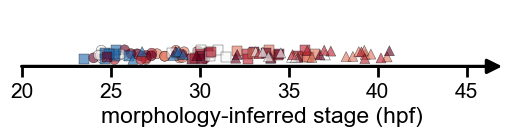

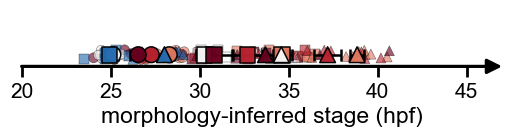

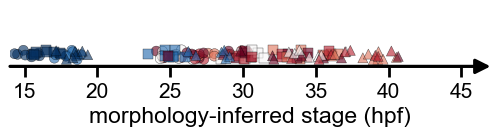

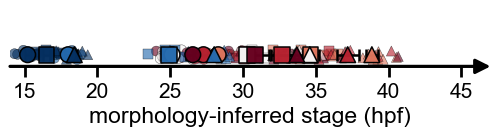

In [8]:
def add_black_x_arrow_axis(ax, *, linewidth=2.3):
    for spine in ax.spines.values():
        spine.set_visible(False)
    ax.grid(False)
    ax.tick_params(axis='x', colors='black', width=2.0, length=8, direction='out')
    ax.tick_params(axis='y', left=False, labelleft=False)
    ax.yaxis.set_visible(False)

    xmin, xmax = ax.get_xlim()
    ax.annotate(
        '',
        xy=(xmax, 0),
        xytext=(xmin, 0),
        xycoords='data',
        textcoords='data',
        arrowprops=dict(
            arrowstyle='-|>',
            color='black',
            lw=linewidth,
            mutation_scale=22,
            shrinkA=0,
            shrinkB=0,
        ),
        clip_on=False,
    )


MORPH_STAGE_STRIP_Y_BASE = 0.04
MORPH_STAGE_STRIP_Y_JITTER = 0.06


def plot_morph_stage_strip(
    individual_data,
    group_data,
    output_stem,
    *,
    xlim,
    include_means=False,
    y_base=MORPH_STAGE_STRIP_Y_BASE,
    y_jitter=MORPH_STAGE_STRIP_Y_JITTER,
):
    rng = np.random.default_rng(20260528)
    individual_plot = individual_data.copy()
    group_plot = group_data.copy()
    individual_plot['strip_y'] = y_base + rng.uniform(0, y_jitter, size=len(individual_plot))
    group_plot['strip_y'] = y_base + (0.5 * y_jitter)

    fig, ax = plt.subplots(figsize=(6.2, 1.35))
    scatter_by_timepoint(
        ax,
        individual_plot,
        'mdl_stage_hpf_registered',
        'strip_y',
        size=52,
        alpha=0.62,
        linewidth=0.35,
        zorder=1,
    )

    if include_means:
        ax.errorbar(
            group_plot['morph_stage_mean_registered'],
            group_plot['strip_y'],
            xerr=group_plot['morph_stage_mean_boot_se'],
            fmt='none',
            ecolor='black',
            elinewidth=1.8,
            capsize=4,
            capthick=1.8,
            alpha=1,
            zorder=3,
        )

        scatter_by_timepoint(
            ax,
            group_plot,
            'morph_stage_mean_registered',
            'strip_y',
            size=128,
            alpha=0.98,
            linewidth=1.1,
            zorder=4,
        )

    ax.set_xlim(*xlim)
    ax.set_ylim(0, max(0.34, y_base + y_jitter + 0.14))
    ax.set_xlabel('morphology-inferred stage (hpf)')
    add_black_x_arrow_axis(ax)

    fig.subplots_adjust(top=0.9, bottom=0.48)

    for suffix in ('png', 'pdf'):
        fig.savefig(OUT_DIR / f'{output_stem}.{suffix}', dpi=300, bbox_inches='tight')

    return fig, ax


fig, ax = plot_morph_stage_strip(
    joint,
    stage_group,
    '01a_morph_stage_registered_strip_single_embryos_only_sac',
    xlim=(20, 47),
)
plt.show()

fig, ax = plot_morph_stage_strip(
    joint,
    stage_group,
    '01a_morph_stage_registered_strip_single_embryos_and_group_means_sac',
    xlim=(20, 47),
    include_means=True,
)
plt.show()

fig, ax = plot_morph_stage_strip(
    joint_all,
    stage_group_all,
    '01a_morph_stage_registered_strip_single_embryos_only_all_temps_sac',
    xlim=(14, 47),
)
plt.show()

fig, ax = plot_morph_stage_strip(
    joint_all,
    stage_group_all,
    '01a_morph_stage_registered_strip_single_embryos_and_group_means_all_temps_sac',
    xlim=(14, 47),
    include_means=True,
)
plt.show()

animation embryos: 109
animation groups: 14
animation axis minimum: 20
animation directory: /Users/nick/Projects/data/morphseq/results/20260528/sac_figs/01a_morph_to_morph_seq_animation_without_early_timepoints
movement frames: 25


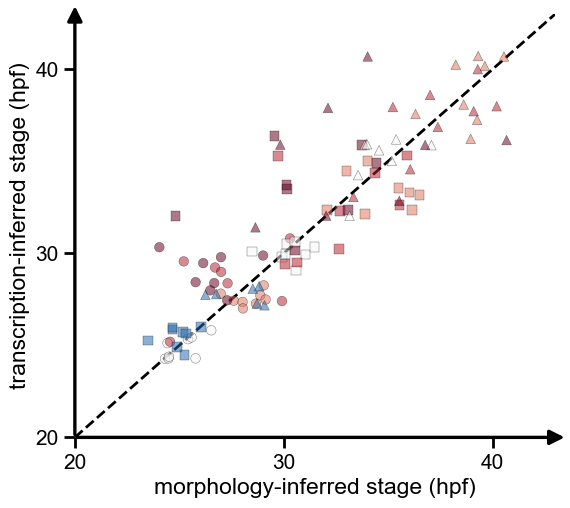

In [9]:
ANIMATION_INCLUDE_EARLY_TIMEPOINTS = False
ANIMATION_N_FRAMES = 25
ANIMATION_AXIS_MIN_WITHOUT_EARLY = 20
ANIMATION_AXIS_MIN_WITH_EARLY = 14
ANIMATION_AXIS_MAX = 43
ANIMATION_POINT_SIZE = 48
ANIMATION_POINT_ALPHA = 0.53
ANIMATION_BASELINE_OFFSET = 0.65

animation_data = joint_all.copy()
animation_early_mask = (
    np.isclose(animation_data['temperature'].astype(float), 19.0)
    | (
        np.isclose(animation_data['temperature'].astype(float), 25.0)
        & np.isclose(animation_data['timepoint'].astype(float), 24.0)
    )
)
if not ANIMATION_INCLUDE_EARLY_TIMEPOINTS:
    animation_data = animation_data.loc[~animation_early_mask].copy()

ANIMATION_AXIS_MIN = (
    ANIMATION_AXIS_MIN_WITH_EARLY
    if ANIMATION_INCLUDE_EARLY_TIMEPOINTS
    else ANIMATION_AXIS_MIN_WITHOUT_EARLY
)
ANIMATION_BASELINE_Y = ANIMATION_AXIS_MIN + ANIMATION_BASELINE_OFFSET

animation_group_data = stage_group_all.copy()
animation_group_early_mask = (
    np.isclose(animation_group_data['temperature'].astype(float), 19.0)
    | (
        np.isclose(animation_group_data['temperature'].astype(float), 25.0)
        & np.isclose(animation_group_data['timepoint'].astype(float), 24.0)
    )
)
if not ANIMATION_INCLUDE_EARLY_TIMEPOINTS:
    animation_group_data = animation_group_data.loc[~animation_group_early_mask].copy()

animation_data = animation_data.sort_values(['temperature', 'timepoint', 'mdl_stage_hpf_registered']).reset_index(drop=True)
animation_group_data = animation_group_data.sort_values(['temperature', 'timepoint']).reset_index(drop=True)
animation_tag = 'with_early_timepoints' if ANIMATION_INCLUDE_EARLY_TIMEPOINTS else 'without_early_timepoints'
animation_dir = OUT_DIR / f'01a_morph_to_morph_seq_animation_{animation_tag}'
movement_dir = animation_dir / 'movement_frames'
movement_dir.mkdir(parents=True, exist_ok=True)
for old_frame in movement_dir.glob('movement_frame_*.png'):
    old_frame.unlink()


def save_animation_step(fig, output_stem, *, output_dir=animation_dir, pdf=True):
    output_dir.mkdir(parents=True, exist_ok=True)
    suffixes = ('png', 'pdf') if pdf else ('png',)
    for suffix in suffixes:
        fig.savefig(output_dir / f'{output_stem}.{suffix}', dpi=300, bbox_inches='tight')


def style_stage_animation_axes(ax, *, show_y_axis=False, show_diagonal=False):
    ax.set_xlim(ANIMATION_AXIS_MIN, ANIMATION_AXIS_MAX)
    ax.set_ylim(ANIMATION_AXIS_MIN, ANIMATION_AXIS_MAX)
    for spine in ax.spines.values():
        spine.set_visible(False)
    ax.grid(False)
    tick_start = int(np.ceil(ANIMATION_AXIS_MIN / 10) * 10)
    ticks = np.arange(tick_start, ANIMATION_AXIS_MAX + 1, 10)
    ax.set_xticks(ticks)
    ax.set_yticks(ticks)
    ax.tick_params(axis='x', colors='black', width=2.0, length=8, direction='out')
    ax.set_xlabel('morphology-inferred stage (hpf)')

    if show_y_axis:
        ax.tick_params(axis='y', colors='black', width=2.0, length=8, direction='out')
        ax.set_ylabel('transcription-inferred stage (hpf)')
    else:
        ax.tick_params(axis='y', left=False, labelleft=False)
        ax.set_ylabel('')

    ax.annotate(
        '',
        xy=(1.025, 0),
        xytext=(0, 0),
        xycoords='axes fraction',
        arrowprops=dict(arrowstyle='-|>', color='black', lw=2.4, mutation_scale=22),
        clip_on=False,
    )
    if show_y_axis:
        ax.annotate(
            '',
            xy=(0, 1.025),
            xytext=(0, 0),
            xycoords='axes fraction',
            arrowprops=dict(arrowstyle='-|>', color='black', lw=2.4, mutation_scale=22),
            clip_on=False,
        )

    if show_diagonal:
        ax.plot(
            [ANIMATION_AXIS_MIN, ANIMATION_AXIS_MAX],
            [ANIMATION_AXIS_MIN, ANIMATION_AXIS_MAX],
            color='black',
            linestyle='--',
            linewidth=2.0,
            zorder=0,
        )


def plot_animation_points(ax, data, x_positions, y_positions):
    plot_data = data.copy()
    plot_data['_animation_x'] = x_positions
    plot_data['_animation_y'] = y_positions
    scatter_by_timepoint(
        ax,
        plot_data,
        '_animation_x',
        '_animation_y',
        size=ANIMATION_POINT_SIZE,
        alpha=ANIMATION_POINT_ALPHA,
        linewidth=0.35,
        zorder=2,
    )


def plot_animation_group_means(ax, group_data):
    ax.errorbar(
        group_data['morph_stage_mean_registered'],
        group_data['seq_stage_mean_registered'],
        xerr=group_data['morph_stage_mean_boot_se'],
        yerr=group_data['seq_stage_mean_boot_se'],
        fmt='none',
        ecolor='black',
        elinewidth=1.8,
        capsize=4,
        capthick=1.8,
        alpha=1,
        zorder=3,
    )
    scatter_by_timepoint(
        ax,
        group_data,
        'morph_stage_mean_registered',
        'seq_stage_mean_registered',
        size=118,
        alpha=0.98,
        linewidth=1.1,
        zorder=4,
    )


initial_x = animation_data['mdl_stage_hpf_registered'].to_numpy()
initial_y = np.full(len(animation_data), ANIMATION_BASELINE_Y)
final_y = animation_data['pseudostage_registered'].to_numpy()

# 00: morphology-only strip, but with the full 2D stage panel already reserved.
fig, ax = plt.subplots(figsize=(6.2, 5.5))
plot_animation_points(ax, animation_data, initial_x, initial_y)
style_stage_animation_axes(ax, show_y_axis=False, show_diagonal=False)
save_animation_step(fig, '00_morph_stage_x_axis_only')
plt.close(fig)

# 01: add the transcription stage axis while points remain on the x-axis baseline.
fig, ax = plt.subplots(figsize=(6.2, 5.5))
plot_animation_points(ax, animation_data, initial_x, initial_y)
style_stage_animation_axes(ax, show_y_axis=True, show_diagonal=False)
save_animation_step(fig, '01_add_transcription_stage_y_axis')
plt.close(fig)

# 02: add the identity line before points lift into their 2D positions.
fig, ax = plt.subplots(figsize=(6.2, 5.5))
plot_animation_points(ax, animation_data, initial_x, initial_y)
style_stage_animation_axes(ax, show_y_axis=True, show_diagonal=True)
save_animation_step(fig, '02_add_identity_line')
plt.close(fig)

final_fig = None
for frame_index, fraction in enumerate(np.linspace(1 / ANIMATION_N_FRAMES, 1, ANIMATION_N_FRAMES), start=1):
    frame_y = initial_y + fraction * (final_y - initial_y)
    fig, ax = plt.subplots(figsize=(6.2, 5.5))
    plot_animation_points(ax, animation_data, initial_x, frame_y)
    style_stage_animation_axes(ax, show_y_axis=True, show_diagonal=True)
    save_animation_step(
        fig,
        f'movement_frame_{frame_index:03d}',
        output_dir=movement_dir,
        pdf=False,
    )
    if frame_index == ANIMATION_N_FRAMES:
        final_fig = fig
    else:
        plt.close(fig)

# 03: final panel with raw embryos plus population means and bootstrap SE bars.
fig, ax = plt.subplots(figsize=(6.2, 5.5))
plot_animation_points(ax, animation_data, initial_x, final_y)
plot_animation_group_means(ax, animation_group_data)
style_stage_animation_axes(ax, show_y_axis=True, show_diagonal=True)
save_animation_step(fig, '03_final_population_means_and_se')
plt.close(fig)

print(f'animation embryos: {len(animation_data)}')
print(f'animation groups: {len(animation_group_data)}')
print(f'animation axis minimum: {ANIMATION_AXIS_MIN}')
print(f'animation directory: {animation_dir}')
print(f'movement frames: {ANIMATION_N_FRAMES}')
plt.show()

## Arrhenius morphology scaling

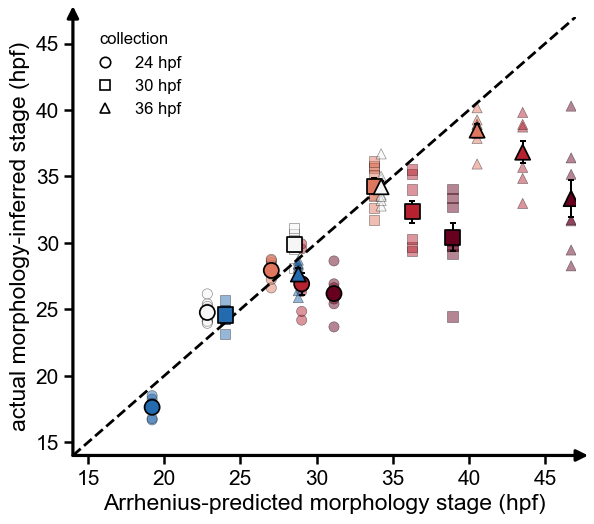

Arrhenius fit temperatures: [25.0, 28.5, 32.0] C
Plotted temperatures: [25.0, 28.5, 32.0, 33.5, 35.0] C; 33.5C is the cached ~34C cohort
Fit parameters: prefactor=2.37179e+06, activation_energy=36940.2
Fit RMSE: 1.631 hpf; plotted-cohort RMSE across embryos: 5.228 hpf
Saved /Users/nick/Projects/data/morphseq/results/20260528/sac_figs/04_arrhenius_morph_prediction_25C_to_32C_plus_34C_35C.png
Saved /Users/nick/Projects/data/morphseq/results/20260528/sac_figs/04_arrhenius_morph_prediction_25C_to_32C_plus_34C_35C.pdf


In [10]:
from scipy.optimize import least_squares

ARRHENIUS_FIT_TEMPS = np.array([25.0, 28.5, 32.0])
ARRHENIUS_PLOT_TEMPS = np.array([25.0, 28.5, 32.0, 33.5, 35.0])  # 33.5C is the cached ~34C cohort.
ARRHENIUS_STAGE_COLUMN = 'mdl_stage_hpf'
ARRHENIUS_AXIS_LIMITS = (14, 47)
ARRHENIUS_R_GAS_CONSTANT = 8.314
ARRHENIUS_RAW_POINT_SIZE = 54
ARRHENIUS_RAW_POINT_ALPHA = 0.48
ARRHENIUS_MEAN_POINT_SIZE = 118


def arrhenius_stage_prediction(time_hpf, temp_c, params, *, gas_constant=ARRHENIUS_R_GAS_CONSTANT):
    temp_k = np.asarray(temp_c, dtype=float) + 273.15
    time_hpf = np.asarray(time_hpf, dtype=float)
    prefactor, activation_energy = params
    return time_hpf * prefactor * np.exp(-activation_energy * (temp_k ** -1) / gas_constant)


def arrhenius_stage_residual(params, time_hpf, temp_c, stage_hpf):
    return arrhenius_stage_prediction(time_hpf, temp_c, params) - np.asarray(stage_hpf, dtype=float)


arrhenius_fit_data = joint_all.loc[
    joint_all['temperature'].astype(float).isin(ARRHENIUS_FIT_TEMPS)
    & joint_all[ARRHENIUS_STAGE_COLUMN].notna()
].copy()
arrhenius_fit_data['temperature'] = arrhenius_fit_data['temperature'].astype(float)
arrhenius_fit_data['timepoint'] = arrhenius_fit_data['timepoint'].astype(float)

arrhenius_fit_result = least_squares(
    arrhenius_stage_residual,
    x0=np.array([1.0, 200.0]),
    args=(
        arrhenius_fit_data['timepoint'].to_numpy(dtype=float),
        arrhenius_fit_data['temperature'].to_numpy(dtype=float),
        arrhenius_fit_data[ARRHENIUS_STAGE_COLUMN].to_numpy(dtype=float),
    ),
    max_nfev=20000,
)

arrhenius_plot_data = joint_all.loc[
    joint_all['temperature'].astype(float).isin(ARRHENIUS_PLOT_TEMPS)
    & joint_all[ARRHENIUS_STAGE_COLUMN].notna()
].copy()
arrhenius_plot_data['temperature'] = arrhenius_plot_data['temperature'].astype(float)
arrhenius_plot_data['timepoint'] = arrhenius_plot_data['timepoint'].astype(float)
arrhenius_plot_data['arrhenius_pred_stage_hpf'] = arrhenius_stage_prediction(
    arrhenius_plot_data['timepoint'].to_numpy(dtype=float),
    arrhenius_plot_data['temperature'].to_numpy(dtype=float),
    arrhenius_fit_result.x,
)

arrhenius_cohort_summary = (
    arrhenius_plot_data
    .groupby(['temperature', 'timepoint'], as_index=False)
    .agg(
        actual_morph_stage_mean=(ARRHENIUS_STAGE_COLUMN, 'mean'),
        actual_morph_stage_se=(ARRHENIUS_STAGE_COLUMN, lambda x: x.std(ddof=1) / np.sqrt(x.count())),
        arrhenius_pred_stage_hpf=('arrhenius_pred_stage_hpf', 'mean'),
        n_embryos=(ARRHENIUS_STAGE_COLUMN, 'count'),
    )
)

fig, ax = plt.subplots(figsize=(6.2, 5.5))

scatter_by_timepoint(
    ax,
    arrhenius_plot_data,
    'arrhenius_pred_stage_hpf',
    ARRHENIUS_STAGE_COLUMN,
    size=ARRHENIUS_RAW_POINT_SIZE,
    alpha=ARRHENIUS_RAW_POINT_ALPHA,
    linewidth=0.45,
    zorder=2,
)

cmap = plt.get_cmap(TEMP_CMAP)
norm = temperature_norm()
for timepoint, group in arrhenius_cohort_summary.groupby('timepoint', sort=True):
    ax.errorbar(
        group['arrhenius_pred_stage_hpf'],
        group['actual_morph_stage_mean'],
        yerr=group['actual_morph_stage_se'],
        fmt='none',
        ecolor='black',
        elinewidth=1.45,
        capsize=2.4,
        capthick=1.45,
        zorder=4,
    )
    ax.scatter(
        group['arrhenius_pred_stage_hpf'],
        group['actual_morph_stage_mean'],
        c=group['temperature'],
        cmap=cmap,
        norm=norm,
        marker=marker_for_timepoint(timepoint),
        s=ARRHENIUS_MEAN_POINT_SIZE,
        edgecolor='black',
        linewidth=1.25,
        zorder=5,
    )

ax.set_xlim(*ARRHENIUS_AXIS_LIMITS)
ax.set_ylim(*ARRHENIUS_AXIS_LIMITS)
ax.set_xticks(np.arange(15, 48, 5))
ax.set_yticks(np.arange(15, 48, 5))
add_identity(ax)
ax.set_xlabel('Arrhenius-predicted morphology stage (hpf)')
ax.set_ylabel('actual morphology-inferred stage (hpf)')
add_black_arrow_axes(ax)
legend = add_timepoint_legend(ax, arrhenius_plot_data['timepoint'])
legend.set_title('collection')
for text in [legend.get_title(), *legend.get_texts()]:
    text.set_color('black')
fig.tight_layout()

arrhenius_base = OUT_DIR / '04_arrhenius_morph_prediction_25C_to_32C_plus_34C_35C'
fig.savefig(arrhenius_base.with_suffix('.png'), dpi=300, bbox_inches='tight')
fig.savefig(arrhenius_base.with_suffix('.pdf'), bbox_inches='tight')
plt.show()

fit_rmse = np.sqrt(np.mean(arrhenius_fit_result.fun ** 2))
plot_rmse = np.sqrt(
    np.mean((arrhenius_plot_data['arrhenius_pred_stage_hpf'] - arrhenius_plot_data[ARRHENIUS_STAGE_COLUMN]) ** 2)
)
print(f'Arrhenius fit temperatures: {ARRHENIUS_FIT_TEMPS.tolist()} C')
print(f'Plotted temperatures: {ARRHENIUS_PLOT_TEMPS.tolist()} C; 33.5C is the cached ~34C cohort')
print(f'Fit parameters: prefactor={arrhenius_fit_result.x[0]:.6g}, activation_energy={arrhenius_fit_result.x[1]:.6g}')
print(f'Fit RMSE: {fit_rmse:.3f} hpf; plotted-cohort RMSE across embryos: {plot_rmse:.3f} hpf')
print(f'Saved {arrhenius_base.with_suffix(".png")}')
print(f'Saved {arrhenius_base.with_suffix(".pdf")}')

In [ ]:
from scipy.optimize import least_squares

ARRHENIUS_FIT_TEMPS = np.array([25.0, 28.5, 32.0])
ARRHENIUS_PLOT_TEMPS = np.array([25.0, 28.5, 32.0, 33.5, 35.0])  # 33.5C is the cached ~34C cohort.
ARRHENIUS_STAGE_COLUMN = 'mdl_stage_hpf'
ARRHENIUS_AXIS_LIMITS = (14, 47)
ARRHENIUS_R_GAS_CONSTANT = 8.314
ARRHENIUS_SD_SIZE_BY_COLLECTION = {24.0: 82, 30.0: 126, 36.0: 176}
ARRHENIUS_SD_OUTPUT_STEM = '04_arrhenius_morph_prediction_25C_to_32C_plus_34C_35C_sd_error_bars_marker_size_by_collection'


def arrhenius_stage_prediction(time_hpf, temp_c, params, *, gas_constant=ARRHENIUS_R_GAS_CONSTANT):
    temp_k = np.asarray(temp_c, dtype=float) + 273.15
    time_hpf = np.asarray(time_hpf, dtype=float)
    prefactor, activation_energy = params
    return time_hpf * prefactor * np.exp(-activation_energy * (temp_k ** -1) / gas_constant)


def arrhenius_stage_residual(params, time_hpf, temp_c, stage_hpf):
    return arrhenius_stage_prediction(time_hpf, temp_c, params) - np.asarray(stage_hpf, dtype=float)


arrhenius_fit_data = joint_all.loc[
    joint_all['temperature'].astype(float).isin(ARRHENIUS_FIT_TEMPS)
    & joint_all[ARRHENIUS_STAGE_COLUMN].notna()
].copy()
arrhenius_fit_data['temperature'] = arrhenius_fit_data['temperature'].astype(float)
arrhenius_fit_data['timepoint'] = arrhenius_fit_data['timepoint'].astype(float)

arrhenius_fit_result = least_squares(
    arrhenius_stage_residual,
    x0=np.array([1.0, 200.0]),
    args=(
        arrhenius_fit_data['timepoint'].to_numpy(dtype=float),
        arrhenius_fit_data['temperature'].to_numpy(dtype=float),
        arrhenius_fit_data[ARRHENIUS_STAGE_COLUMN].to_numpy(dtype=float),
    ),
    max_nfev=20000,
)

arrhenius_plot_data = joint_all.loc[
    joint_all['temperature'].astype(float).isin(ARRHENIUS_PLOT_TEMPS)
    & joint_all[ARRHENIUS_STAGE_COLUMN].notna()
].copy()
arrhenius_plot_data['temperature'] = arrhenius_plot_data['temperature'].astype(float)
arrhenius_plot_data['timepoint'] = arrhenius_plot_data['timepoint'].astype(float)
arrhenius_plot_data['arrhenius_pred_stage_hpf'] = arrhenius_stage_prediction(
    arrhenius_plot_data['timepoint'].to_numpy(dtype=float),
    arrhenius_plot_data['temperature'].to_numpy(dtype=float),
    arrhenius_fit_result.x,
)

arrhenius_cohort_summary = (
    arrhenius_plot_data
    .groupby(['temperature', 'timepoint'], as_index=False)
    .agg(
        actual_morph_stage_mean=(ARRHENIUS_STAGE_COLUMN, 'mean'),
        actual_morph_stage_sd=(ARRHENIUS_STAGE_COLUMN, lambda x: x.std(ddof=1)),
        arrhenius_pred_stage_hpf=('arrhenius_pred_stage_hpf', 'mean'),
        n_embryos=(ARRHENIUS_STAGE_COLUMN, 'count'),
    )
)

fig, ax = plt.subplots(figsize=(6.2, 5.5))

ax.errorbar(
    arrhenius_cohort_summary['arrhenius_pred_stage_hpf'],
    arrhenius_cohort_summary['actual_morph_stage_mean'],
    yerr=arrhenius_cohort_summary['actual_morph_stage_sd'],
    fmt='none',
    ecolor='black',
    elinewidth=1.8,
    capsize=4,
    capthick=1.8,
    alpha=1,
    zorder=2,
)

cmap = plt.get_cmap(TEMP_CMAP)
norm = temperature_norm()
for timepoint, group in arrhenius_cohort_summary.groupby('timepoint', sort=True):
    ax.scatter(
        group['arrhenius_pred_stage_hpf'],
        group['actual_morph_stage_mean'],
        c=group['temperature'],
        cmap=cmap,
        norm=norm,
        marker='o',
        s=ARRHENIUS_SD_SIZE_BY_COLLECTION.get(float(timepoint), 126),
        alpha=0.98,
        edgecolor='black',
        linewidth=1.1,
        zorder=3,
    )

ax.set_xlim(*ARRHENIUS_AXIS_LIMITS)
ax.set_ylim(*ARRHENIUS_AXIS_LIMITS)
ax.set_xticks(np.arange(15, 48, 5))
ax.set_yticks(np.arange(15, 48, 5))
add_identity(ax)
ax.set_xlabel('Arrhenius-predicted morphology stage (hpf)')
ax.set_ylabel('actual morphology-inferred stage (hpf)')
add_black_arrow_axes(ax)

legend_handles = []
for timepoint in sorted(arrhenius_cohort_summary['timepoint'].unique()):
    legend_handles.append(
        Line2D(
            [0],
            [0],
            marker='o',
            linestyle='none',
            markerfacecolor='white',
            markeredgecolor='black',
            markeredgewidth=1.1,
            markersize=np.sqrt(ARRHENIUS_SD_SIZE_BY_COLLECTION.get(float(timepoint), 126)),
            label=f'{float(timepoint):g} hpf',
        )
    )
legend = ax.legend(handles=legend_handles, title='collection', frameon=False, loc='best')
for text in [legend.get_title(), *legend.get_texts()]:
    text.set_color('black')

fig.tight_layout()
for suffix in ('png', 'pdf'):
    fig.savefig(OUT_DIR / f'{ARRHENIUS_SD_OUTPUT_STEM}.{suffix}', dpi=300, bbox_inches='tight')
plt.show()

fit_rmse = np.sqrt(np.mean(arrhenius_fit_result.fun ** 2))
print(f'Arrhenius fit temperatures: {ARRHENIUS_FIT_TEMPS.tolist()} C')
print(f'Plotted temperatures: {ARRHENIUS_PLOT_TEMPS.tolist()} C; 33.5C is the cached ~34C cohort')
print(f'Fit RMSE: {fit_rmse:.3f} hpf')
print(f'cohort means plotted: {len(arrhenius_cohort_summary)}')
print(f'Saved {OUT_DIR / f"{ARRHENIUS_SD_OUTPUT_STEM}.png"}')
print(f'Saved {OUT_DIR / f"{ARRHENIUS_SD_OUTPUT_STEM}.pdf"}')


## Arrhenius morphology and transcription overlay

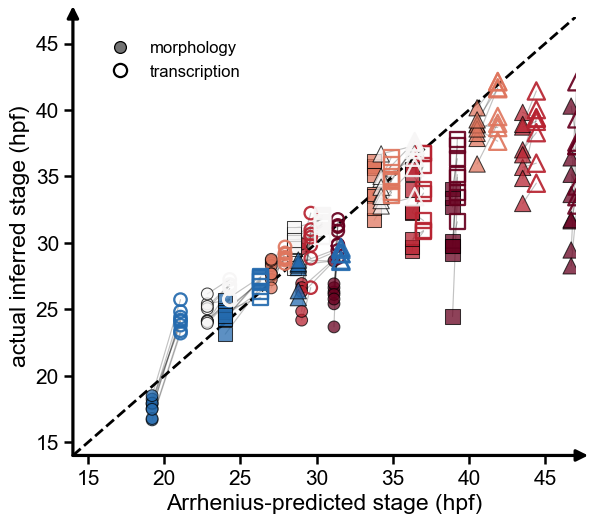

Arrhenius fit temperatures: [25.0, 28.5, 32.0] C
Plotted temperatures: [25.0, 28.5, 32.0, 33.5, 35.0] C; 33.5C is the cached ~34C cohort
Transcription Arrhenius fit excludes temperature/timepoint pairs: [(25.0, 24.0)]
Morph fit RMSE: 1.631 hpf; transcription fit RMSE: 1.617 hpf
Saved /Users/nick/Projects/data/morphseq/results/20260528/sac_figs/05_arrhenius_morph_transcription_prediction_connected_25C_to_32C_plus_34C_35C.png
Saved /Users/nick/Projects/data/morphseq/results/20260528/sac_figs/05_arrhenius_morph_transcription_prediction_connected_25C_to_32C_plus_34C_35C.pdf


In [11]:
ARRHENIUS_DUAL_FIT_TEMPS = np.array([25.0, 28.5, 32.0])
ARRHENIUS_DUAL_PLOT_TEMPS = np.array([25.0, 28.5, 32.0, 33.5, 35.0])  # 33.5C is the cached ~34C cohort.
ARRHENIUS_DUAL_SEQ_FIT_EXCLUDE = [(25.0, 24.0)]
ARRHENIUS_DUAL_AXIS_LIMITS = (14, 47)
ARRHENIUS_COLLECTION_MARKER_SIZE = {24.0: 72, 30.0: 104, 36.0: 138}
ARRHENIUS_DUAL_POINT_ALPHA = 0.74
ARRHENIUS_DUAL_LINE_ALPHA = 0.24
ARRHENIUS_DUAL_LINEWIDTH = 0.85


def fit_arrhenius_stage_model(data, stage_column, *, exclude_temperature_timepoints=None):
    fit_data = data.loc[
        data['temperature'].astype(float).isin(ARRHENIUS_DUAL_FIT_TEMPS)
        & data[stage_column].notna()
    ].copy()
    fit_data['temperature'] = fit_data['temperature'].astype(float)
    fit_data['timepoint'] = fit_data['timepoint'].astype(float)
    if exclude_temperature_timepoints:
        for temperature, timepoint in exclude_temperature_timepoints:
            exclude_mask = np.isclose(fit_data['temperature'], temperature) & np.isclose(fit_data['timepoint'], timepoint)
            fit_data = fit_data.loc[~exclude_mask].copy()
    return least_squares(
        arrhenius_stage_residual,
        x0=np.array([1.0, 200.0]),
        args=(
            fit_data['timepoint'].to_numpy(dtype=float),
            fit_data['temperature'].to_numpy(dtype=float),
            fit_data[stage_column].to_numpy(dtype=float),
        ),
        max_nfev=20000,
    )


arrhenius_dual_data = joint_all.loc[
    joint_all['temperature'].astype(float).isin(ARRHENIUS_DUAL_PLOT_TEMPS)
    & joint_all['mdl_stage_hpf'].notna()
    & joint_all['pseudostage'].notna()
].copy()
arrhenius_dual_data['temperature'] = arrhenius_dual_data['temperature'].astype(float)
arrhenius_dual_data['timepoint'] = arrhenius_dual_data['timepoint'].astype(float)

arrhenius_dual_morph_fit = fit_arrhenius_stage_model(joint_all, 'mdl_stage_hpf')
arrhenius_dual_seq_fit = fit_arrhenius_stage_model(
    joint_all,
    'pseudostage',
    exclude_temperature_timepoints=ARRHENIUS_DUAL_SEQ_FIT_EXCLUDE,
)
arrhenius_dual_data['morph_arrhenius_pred_stage_hpf'] = arrhenius_stage_prediction(
    arrhenius_dual_data['timepoint'].to_numpy(dtype=float),
    arrhenius_dual_data['temperature'].to_numpy(dtype=float),
    arrhenius_dual_morph_fit.x,
)
arrhenius_dual_data['seq_arrhenius_pred_stage_hpf'] = arrhenius_stage_prediction(
    arrhenius_dual_data['timepoint'].to_numpy(dtype=float),
    arrhenius_dual_data['temperature'].to_numpy(dtype=float),
    arrhenius_dual_seq_fit.x,
)

fig, ax = plt.subplots(figsize=(6.2, 5.5))
cmap = plt.get_cmap(TEMP_CMAP)
norm = temperature_norm()

for row in arrhenius_dual_data.itertuples(index=False):
    ax.plot(
        [row.morph_arrhenius_pred_stage_hpf, row.seq_arrhenius_pred_stage_hpf],
        [row.mdl_stage_hpf, row.pseudostage],
        color='black',
        linewidth=ARRHENIUS_DUAL_LINEWIDTH,
        alpha=ARRHENIUS_DUAL_LINE_ALPHA,
        solid_capstyle='round',
        zorder=1,
    )

for timepoint, group in arrhenius_dual_data.groupby('timepoint', sort=True):
    marker_size = ARRHENIUS_COLLECTION_MARKER_SIZE.get(float(timepoint), 96)
    colors = cmap(norm(group['temperature'].to_numpy(dtype=float)))
    ax.scatter(
        group['morph_arrhenius_pred_stage_hpf'],
        group['mdl_stage_hpf'],
        c=group['temperature'],
        cmap=cmap,
        norm=norm,
        marker=marker_for_timepoint(timepoint),
        s=marker_size,
        alpha=ARRHENIUS_DUAL_POINT_ALPHA,
        edgecolor='black',
        linewidth=0.75,
        rasterized=True,
        zorder=3,
    )
    ax.scatter(
        group['seq_arrhenius_pred_stage_hpf'],
        group['pseudostage'],
        facecolors='none',
        edgecolors=colors,
        marker=marker_for_timepoint(timepoint),
        s=marker_size * 1.12,
        alpha=0.92,
        linewidth=1.65,
        rasterized=True,
        zorder=4,
    )

ax.set_xlim(*ARRHENIUS_DUAL_AXIS_LIMITS)
ax.set_ylim(*ARRHENIUS_DUAL_AXIS_LIMITS)
ax.set_xticks(np.arange(15, 48, 5))
ax.set_yticks(np.arange(15, 48, 5))
add_identity(ax)
ax.set_xlabel('Arrhenius-predicted stage (hpf)')
ax.set_ylabel('actual inferred stage (hpf)')
add_black_arrow_axes(ax)

source_handles = [
    Line2D(
        [0], [0], marker='o', linestyle='none', markerfacecolor='0.45', markeredgecolor='black',
        markeredgewidth=0.9, markersize=8.5, label='morphology'
    ),
    Line2D(
        [0], [0], marker='o', linestyle='none', markerfacecolor='none', markeredgecolor='black',
        markeredgewidth=1.6, markersize=9.5, label='transcription'
    ),
]
source_legend = ax.legend(handles=source_handles, frameon=False, loc='upper left', bbox_to_anchor=(0.03, 0.98))
for text in source_legend.get_texts():
    text.set_color('black')
fig.tight_layout()

arrhenius_dual_base = OUT_DIR / '05_arrhenius_morph_transcription_prediction_connected_25C_to_32C_plus_34C_35C'
fig.savefig(arrhenius_dual_base.with_suffix('.png'), dpi=300, bbox_inches='tight')
fig.savefig(arrhenius_dual_base.with_suffix('.pdf'), bbox_inches='tight')
plt.show()

morph_fit_rmse = np.sqrt(np.mean(arrhenius_dual_morph_fit.fun ** 2))
seq_fit_rmse = np.sqrt(np.mean(arrhenius_dual_seq_fit.fun ** 2))
print(f'Arrhenius fit temperatures: {ARRHENIUS_DUAL_FIT_TEMPS.tolist()} C')
print(f'Plotted temperatures: {ARRHENIUS_DUAL_PLOT_TEMPS.tolist()} C; 33.5C is the cached ~34C cohort')
print(f'Transcription Arrhenius fit excludes temperature/timepoint pairs: {ARRHENIUS_DUAL_SEQ_FIT_EXCLUDE}')
print(f'Morph fit RMSE: {morph_fit_rmse:.3f} hpf; transcription fit RMSE: {seq_fit_rmse:.3f} hpf')
print(f'Saved {arrhenius_dual_base.with_suffix(".png")}')
print(f'Saved {arrhenius_dual_base.with_suffix(".pdf")}')

## Paired morphology and transcription stage strip plot

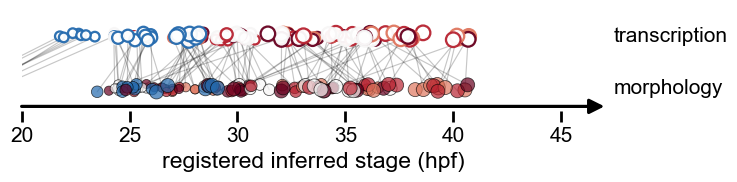

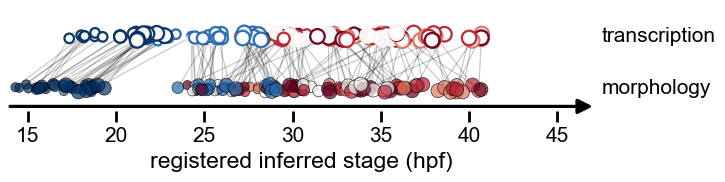

In [12]:
PAIRED_STAGE_STRIP_Y_MORPH = 0.11
PAIRED_STAGE_STRIP_Y_SEQ = 0.42
PAIRED_STAGE_STRIP_Y_JITTER = 0.025
PAIRED_STAGE_STRIP_MARKER_SIZE = {24.0: 44, 30.0: 70, 36.0: 102}
PAIRED_STAGE_STRIP_POINT_ALPHA = 0.70
PAIRED_STAGE_STRIP_LINE_ALPHA = 0.22


def plot_paired_morph_seq_stage_strip(
    individual_data,
    output_stem,
    *,
    xlim,
    y_morph=PAIRED_STAGE_STRIP_Y_MORPH,
    y_seq=PAIRED_STAGE_STRIP_Y_SEQ,
    y_jitter=PAIRED_STAGE_STRIP_Y_JITTER,
):
    rng = np.random.default_rng(20260528)
    plot_data = individual_data.loc[
        individual_data['mdl_stage_hpf_registered'].notna()
        & individual_data['pseudostage_registered'].notna()
    ].copy()
    plot_data['temperature'] = plot_data['temperature'].astype(float)
    plot_data['timepoint'] = plot_data['timepoint'].astype(float)
    plot_data['pair_y_jitter'] = rng.uniform(-y_jitter, y_jitter, size=len(plot_data))
    plot_data['morph_y'] = y_morph + plot_data['pair_y_jitter']
    plot_data['seq_y'] = y_seq + plot_data['pair_y_jitter']
    plot_data['marker_size'] = plot_data['timepoint'].map(PAIRED_STAGE_STRIP_MARKER_SIZE).fillna(64)

    cmap = plt.get_cmap(TEMP_CMAP)
    norm = temperature_norm()
    point_colors = cmap(norm(plot_data['temperature'].to_numpy(dtype=float)))

    fig, ax = plt.subplots(figsize=(6.2, 1.95))

    for row in plot_data.itertuples(index=False):
        ax.plot(
            [row.mdl_stage_hpf_registered, row.pseudostage_registered],
            [row.morph_y, row.seq_y],
            color='black',
            linewidth=0.85,
            alpha=PAIRED_STAGE_STRIP_LINE_ALPHA,
            solid_capstyle='round',
            zorder=1,
        )

    ax.scatter(
        plot_data['mdl_stage_hpf_registered'],
        plot_data['morph_y'],
        c=plot_data['temperature'],
        cmap=cmap,
        norm=norm,
        marker='o',
        s=plot_data['marker_size'],
        alpha=PAIRED_STAGE_STRIP_POINT_ALPHA,
        edgecolor='black',
        linewidth=0.55,
        rasterized=True,
        zorder=2,
    )
    ax.scatter(
        plot_data['pseudostage_registered'],
        plot_data['seq_y'],
        facecolors='white',
        edgecolors=point_colors,
        marker='o',
        s=plot_data['marker_size'] * 1.08,
        alpha=0.95,
        linewidth=1.65,
        rasterized=True,
        zorder=3,
    )

    ax.text(
        1.015,
        y_seq,
        'transcription',
        transform=ax.get_yaxis_transform(),
        ha='left',
        va='center',
        color='black',
        fontsize=mpl.rcParams['font.size'],
        clip_on=False,
    )
    ax.text(
        1.015,
        y_morph,
        'morphology',
        transform=ax.get_yaxis_transform(),
        ha='left',
        va='center',
        color='black',
        fontsize=mpl.rcParams['font.size'],
        clip_on=False,
    )

    ax.set_xlim(*xlim)
    ax.set_ylim(-0.03, 0.58)
    ax.set_xticks(np.arange(np.ceil(xlim[0] / 5) * 5, xlim[1] + 1, 5))
    ax.set_xlabel('registered inferred stage (hpf)')
    add_black_x_arrow_axis(ax)
    fig.subplots_adjust(top=0.9, bottom=0.38, left=0.04, right=0.98)

    for suffix in ('png', 'pdf'):
        fig.savefig(OUT_DIR / f'{output_stem}.{suffix}', dpi=300, bbox_inches='tight')

    return fig, ax


fig, ax = plot_paired_morph_seq_stage_strip(
    joint,
    '06_morph_seq_stage_registered_pair_strip_no19C_sac',
    xlim=(20, 47),
)
plt.show()

fig, ax = plot_paired_morph_seq_stage_strip(
    joint_all,
    '06_morph_seq_stage_registered_pair_strip_all_temps_sac',
    xlim=(14, 47),
)
plt.show()

## Linear developmental rate by temperature

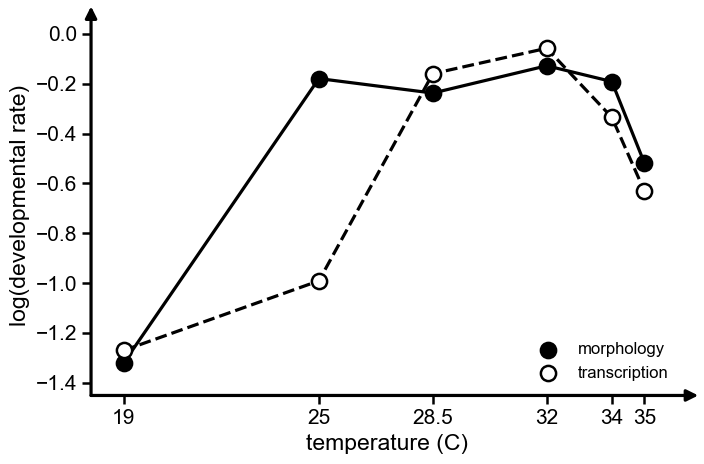

Transcription rate fit excluded temperature/timepoint pairs: [(25.0, 24.0)]
     modality  temperature     rate  log_rate  intercept  n_cohorts_fit timepoints_fit     fit_rmse  temperature_plot
   morphology         19.0 0.266882 -1.320948   8.707846              3       24,30,36 1.420809e-01              19.0
   morphology         25.0 0.835646 -0.179550  -1.416654              3       24,30,36 9.088694e-01              25.0
   morphology         28.5 0.788413 -0.237733   6.347610              3       24,30,36 1.971630e-01              28.5
   morphology         32.0 0.879678 -0.128199   7.539095              3       24,30,36 5.022933e-01              32.0
   morphology         33.5 0.825728 -0.191490   7.620700              3       24,30,36 2.161424e-01              34.0
   morphology         35.0 0.595629 -0.518137  12.483647              3       24,30,36 3.211862e-01              35.0
transcription         19.0 0.280703 -1.270457  11.982919              3       24,30,36 5.236889e-0

In [13]:
LINEAR_RATE_TRANSCRIPTION_EXCLUDE = {(25.0, 24.0)}
LINEAR_RATE_OUTPUT_STEM = '07_linear_developmental_rate_log_rate_by_temperature_sac'
LINEAR_RATE_TABLE_PATH = OUT_DIR / '07_linear_developmental_rate_estimates_by_temperature.csv'


def fit_cohort_mean_stage_rate(cohort_table, stage_column, *, modality):
    rows = []
    for temperature, temp_group in cohort_table.groupby('temperature', sort=True):
        fit_group = temp_group.copy()
        if modality == 'transcription':
            for exclude_temp, exclude_timepoint in LINEAR_RATE_TRANSCRIPTION_EXCLUDE:
                exclude_mask = (
                    np.isclose(fit_group['temperature'].astype(float), exclude_temp)
                    & np.isclose(fit_group['timepoint'].astype(float), exclude_timepoint)
                )
                fit_group = fit_group.loc[~exclude_mask].copy()

        time_hpf = fit_group['timepoint'].to_numpy(dtype=float)
        stage_hpf = fit_group[stage_column].to_numpy(dtype=float)
        rate, intercept = np.polyfit(time_hpf, stage_hpf, deg=1)
        fitted_stage = intercept + rate * time_hpf
        rows.append(
            {
                'modality': modality,
                'temperature': float(temperature),
                'rate': rate,
                'log_rate': np.log(rate),
                'intercept': intercept,
                'n_cohorts_fit': len(fit_group),
                'timepoints_fit': ','.join(f'{tp:g}' for tp in sorted(time_hpf)),
                'fit_rmse': np.sqrt(np.mean((fitted_stage - stage_hpf) ** 2)),
            }
        )
    return rows


linear_rate_rows = []
linear_rate_rows.extend(
    fit_cohort_mean_stage_rate(
        stage_group_all,
        'morph_stage_mean_registered',
        modality='morphology',
    )
)
linear_rate_rows.extend(
    fit_cohort_mean_stage_rate(
        stage_group_all,
        'seq_stage_mean_registered',
        modality='transcription',
    )
)
linear_rate_df = pd.DataFrame(linear_rate_rows)
linear_rate_df['temperature_plot'] = linear_rate_df['temperature'].where(
    ~np.isclose(linear_rate_df['temperature'], 33.5),
    34.0,
)
linear_rate_df.to_csv(LINEAR_RATE_TABLE_PATH, index=False)

fig, ax = plt.subplots(figsize=(7.3, 4.9))
modality_style = {
    'morphology': {
        'label': 'morphology',
        'marker': 'o',
        'facecolor': 'black',
        'edgecolor': 'black',
        'linestyle': '-',
    },
    'transcription': {
        'label': 'transcription',
        'marker': 'o',
        'facecolor': 'white',
        'edgecolor': 'black',
        'linestyle': '--',
    },
}

for modality, group in linear_rate_df.groupby('modality', sort=False):
    group = group.sort_values('temperature_plot')
    style = modality_style[modality]
    ax.plot(
        group['temperature_plot'],
        group['log_rate'],
        color='black',
        linewidth=2.3,
        linestyle=style['linestyle'],
        zorder=1,
    )
    ax.scatter(
        group['temperature_plot'],
        group['log_rate'],
        marker=style['marker'],
        s=120,
        facecolor=style['facecolor'],
        edgecolor=style['edgecolor'],
        linewidth=1.8,
        label=style['label'],
        zorder=3,
    )

ax.set_xlim(18, 36.2)
ax.set_ylim(linear_rate_df['log_rate'].min() - 0.13, linear_rate_df['log_rate'].max() + 0.13)
ax.set_xticks(sorted(linear_rate_df['temperature_plot'].unique()))
ax.set_xticklabels([f'{temp:g}' for temp in sorted(linear_rate_df['temperature_plot'].unique())])
ax.set_xlabel('temperature (C)')
ax.set_ylabel('log(developmental rate)')
add_black_arrow_axes(ax)
legend = ax.legend(frameon=False, loc='lower right')
for text in legend.get_texts():
    text.set_color('black')
fig.tight_layout()

linear_rate_base = OUT_DIR / LINEAR_RATE_OUTPUT_STEM
fig.savefig(linear_rate_base.with_suffix('.png'), dpi=300, bbox_inches='tight')
fig.savefig(linear_rate_base.with_suffix('.pdf'), bbox_inches='tight')
plt.show()

print(f'Transcription rate fit excluded temperature/timepoint pairs: {sorted(LINEAR_RATE_TRANSCRIPTION_EXCLUDE)}')
print(linear_rate_df.sort_values(['modality', 'temperature']).to_string(index=False))
print(f'Saved {linear_rate_base.with_suffix(".png")}')
print(f'Saved {linear_rate_base.with_suffix(".pdf")}')
print(f'Saved {LINEAR_RATE_TABLE_PATH}')

## Linear developmental rate by inverse temperature

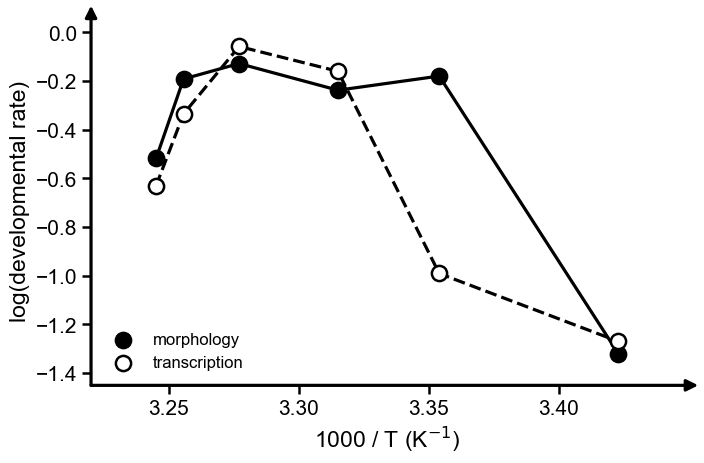

Saved /Users/nick/Projects/data/morphseq/results/20260528/sac_figs/08_linear_developmental_rate_log_rate_by_inverse_temperature_sac.png
Saved /Users/nick/Projects/data/morphseq/results/20260528/sac_figs/08_linear_developmental_rate_log_rate_by_inverse_temperature_sac.pdf


In [14]:
LINEAR_RATE_INV_TEMP_OUTPUT_STEM = '08_linear_developmental_rate_log_rate_by_inverse_temperature_sac'
linear_rate_inv_temp_df = linear_rate_df.copy()
linear_rate_inv_temp_df['temperature_for_inverse_plot'] = linear_rate_inv_temp_df.get(
    'temperature_plot',
    linear_rate_inv_temp_df['temperature'],
)
linear_rate_inv_temp_df['inverse_temp_k_x1000'] = 1000 / (linear_rate_inv_temp_df['temperature_for_inverse_plot'] + 273.15)

fig, ax = plt.subplots(figsize=(7.3, 4.9))

for modality, group in linear_rate_inv_temp_df.groupby('modality', sort=False):
    group = group.sort_values('inverse_temp_k_x1000')
    style = modality_style[modality]
    ax.plot(
        group['inverse_temp_k_x1000'],
        group['log_rate'],
        color='black',
        linewidth=2.3,
        linestyle=style['linestyle'],
        zorder=1,
    )
    ax.scatter(
        group['inverse_temp_k_x1000'],
        group['log_rate'],
        marker=style['marker'],
        s=120,
        facecolor=style['facecolor'],
        edgecolor=style['edgecolor'],
        linewidth=1.8,
        label=style['label'],
        zorder=3,
    )

xpad = 0.025
ax.set_xlim(
    linear_rate_inv_temp_df['inverse_temp_k_x1000'].min() - xpad,
    linear_rate_inv_temp_df['inverse_temp_k_x1000'].max() + xpad,
)
ax.set_ylim(linear_rate_inv_temp_df['log_rate'].min() - 0.13, linear_rate_inv_temp_df['log_rate'].max() + 0.13)
ax.set_xlabel('1000 / T (K$^{-1}$)')
ax.set_ylabel('log(developmental rate)')
add_black_arrow_axes(ax)
legend = ax.legend(frameon=False, loc='lower left')
for text in legend.get_texts():
    text.set_color('black')
fig.tight_layout()

linear_rate_inv_temp_base = OUT_DIR / LINEAR_RATE_INV_TEMP_OUTPUT_STEM
fig.savefig(linear_rate_inv_temp_base.with_suffix('.png'), dpi=300, bbox_inches='tight')
fig.savefig(linear_rate_inv_temp_base.with_suffix('.pdf'), bbox_inches='tight')
plt.show()

print(f'Saved {linear_rate_inv_temp_base.with_suffix(".png")}')
print(f'Saved {linear_rate_inv_temp_base.with_suffix(".pdf")}')

## Stage-specific mean-only morph-to-seq animations

In [15]:
STAGE_SPLIT_ANIMATION_N_FRAMES = 25
STAGE_SPLIT_ANIMATION_AXIS_MIN = 20
STAGE_SPLIT_ANIMATION_AXIS_MAX = 43
STAGE_SPLIT_ANIMATION_BASELINE_Y = STAGE_SPLIT_ANIMATION_AXIS_MIN + 0.65
STAGE_SPLIT_RAW_POINT_SIZE = 54
STAGE_SPLIT_RAW_POINT_ALPHA = 0.53
STAGE_SPLIT_MEAN_POINT_SIZE = 138
STAGE_SPLIT_MEAN_POINT_ALPHA = 0.98
STAGE_SPLIT_OUTPUT_DIR = OUT_DIR / '01a_morph_to_morph_seq_animation_without_early_timepoints_by_collection_stage'
STAGE_SPECIFIC_TEMP_STAGE_Y_LIMITS = (20, 42.5)

stage_split_animation_data = joint_all.copy()
stage_split_early_mask = (
    np.isclose(stage_split_animation_data['temperature'].astype(float), 19.0)
    | (
        np.isclose(stage_split_animation_data['temperature'].astype(float), 25.0)
        & np.isclose(stage_split_animation_data['timepoint'].astype(float), 24.0)
    )
)
stage_split_animation_data = stage_split_animation_data.loc[~stage_split_early_mask].copy()
stage_split_animation_data['temperature'] = stage_split_animation_data['temperature'].astype(float)
stage_split_animation_data['temperature_plot'] = stage_split_animation_data['temperature'].where(
    ~np.isclose(stage_split_animation_data['temperature'], 33.5),
    34.0,
)
stage_split_animation_data['timepoint'] = stage_split_animation_data['timepoint'].astype(float)

stage_split_group_data = stage_group_all.copy()
stage_split_group_early_mask = (
    np.isclose(stage_split_group_data['temperature'].astype(float), 19.0)
    | (
        np.isclose(stage_split_group_data['temperature'].astype(float), 25.0)
        & np.isclose(stage_split_group_data['timepoint'].astype(float), 24.0)
    )
)
stage_split_group_data = stage_split_group_data.loc[~stage_split_group_early_mask].copy()
stage_split_group_data['temperature'] = stage_split_group_data['temperature'].astype(float)
stage_split_group_data['temperature_plot'] = stage_split_group_data['temperature'].where(
    ~np.isclose(stage_split_group_data['temperature'], 33.5),
    34.0,
)
stage_split_group_data['timepoint'] = stage_split_group_data['timepoint'].astype(float)


def save_stage_split_animation_step(fig, output_stem, *, output_dir, pdf=True):
    output_dir.mkdir(parents=True, exist_ok=True)
    suffixes = ('png', 'pdf') if pdf else ('png',)
    for suffix in suffixes:
        fig.savefig(output_dir / f'{output_stem}.{suffix}', dpi=300, bbox_inches='tight')


def style_stage_split_animation_axes(ax, *, show_y_axis=False, show_diagonal=False):
    ax.set_xlim(STAGE_SPLIT_ANIMATION_AXIS_MIN, STAGE_SPLIT_ANIMATION_AXIS_MAX)
    ax.set_ylim(STAGE_SPLIT_ANIMATION_AXIS_MIN, STAGE_SPLIT_ANIMATION_AXIS_MAX)
    for spine in ax.spines.values():
        spine.set_visible(False)
    ax.grid(False)
    ticks = np.arange(STAGE_SPLIT_ANIMATION_AXIS_MIN, STAGE_SPLIT_ANIMATION_AXIS_MAX + 1, 10)
    ax.set_xticks(ticks)
    ax.set_yticks(ticks)
    ax.tick_params(axis='x', colors='black', width=2.0, length=8, direction='out')
    ax.set_xlabel('morphology-inferred stage (hpf)')

    if show_y_axis:
        ax.tick_params(axis='y', colors='black', width=2.0, length=8, direction='out')
        ax.set_ylabel('transcription-inferred stage (hpf)')
    else:
        ax.tick_params(axis='y', left=False, labelleft=False)
        ax.set_ylabel('')

    ax.annotate(
        '',
        xy=(1.025, 0),
        xytext=(0, 0),
        xycoords='axes fraction',
        arrowprops=dict(arrowstyle='-|>', color='black', lw=2.4, mutation_scale=22),
        clip_on=False,
    )
    if show_y_axis:
        ax.annotate(
            '',
            xy=(0, 1.025),
            xytext=(0, 0),
            xycoords='axes fraction',
            arrowprops=dict(arrowstyle='-|>', color='black', lw=2.4, mutation_scale=22),
            clip_on=False,
        )

    if show_diagonal:
        ax.plot(
            [STAGE_SPLIT_ANIMATION_AXIS_MIN, STAGE_SPLIT_ANIMATION_AXIS_MAX],
            [STAGE_SPLIT_ANIMATION_AXIS_MIN, STAGE_SPLIT_ANIMATION_AXIS_MAX],
            color='black',
            linestyle='--',
            linewidth=2.0,
            zorder=0,
        )


def plot_stage_split_raw_points(ax, stage_data):
    cmap = plt.get_cmap(TEMP_CMAP)
    norm = temperature_norm()
    ax.scatter(
        stage_data['mdl_stage_hpf_registered'],
        np.full(len(stage_data), STAGE_SPLIT_ANIMATION_BASELINE_Y),
        c=stage_data['temperature'],
        cmap=cmap,
        norm=norm,
        marker='o',
        s=STAGE_SPLIT_RAW_POINT_SIZE,
        alpha=STAGE_SPLIT_RAW_POINT_ALPHA,
        edgecolor='black',
        linewidth=0.35,
        rasterized=True,
        zorder=2,
    )


def plot_stage_split_mean_points(
    ax,
    stage_group,
    *,
    fraction=0,
    y_axis=False,
    include_seq_yerr=True,
):
    cmap = plt.get_cmap(TEMP_CMAP)
    norm = temperature_norm()
    x = stage_group['morph_stage_mean_registered'].to_numpy(dtype=float)
    y0 = np.full(len(stage_group), STAGE_SPLIT_ANIMATION_BASELINE_Y)
    y1 = stage_group['seq_stage_mean_registered'].to_numpy(dtype=float)
    y = y0 + fraction * (y1 - y0)
    yerr = None
    if y_axis and include_seq_yerr:
        yerr = fraction * stage_group['seq_stage_mean_boot_se'].to_numpy(dtype=float)

    ax.errorbar(
        x,
        y,
        xerr=stage_group['morph_stage_mean_boot_se'].to_numpy(dtype=float),
        yerr=yerr,
        fmt='none',
        ecolor='black',
        elinewidth=1.8,
        capsize=4,
        capthick=1.8,
        alpha=1,
        zorder=3,
    )
    ax.scatter(
        x,
        y,
        c=stage_group['temperature'],
        cmap=cmap,
        norm=norm,
        marker='o',
        s=STAGE_SPLIT_MEAN_POINT_SIZE,
        alpha=STAGE_SPLIT_MEAN_POINT_ALPHA,
        edgecolor='black',
        linewidth=1.1,
        zorder=4,
    )


def make_stage_split_animation_for_timepoint(timepoint):
    stage_data = (
        stage_split_animation_data
        .loc[np.isclose(stage_split_animation_data['timepoint'], timepoint)]
        .sort_values(['temperature', 'mdl_stage_hpf_registered'])
        .reset_index(drop=True)
    )
    stage_group = (
        stage_split_group_data
        .loc[np.isclose(stage_split_group_data['timepoint'], timepoint)]
        .sort_values(['temperature'])
        .reset_index(drop=True)
    )

    stage_dir = STAGE_SPLIT_OUTPUT_DIR / f'{int(timepoint):02d}_hpf'
    movement_dir = stage_dir / 'movement_frames'
    stage_dir.mkdir(parents=True, exist_ok=True)
    movement_dir.mkdir(parents=True, exist_ok=True)
    for old_file in stage_dir.glob('*.png'):
        old_file.unlink()
    for old_file in stage_dir.glob('*.pdf'):
        old_file.unlink()
    for old_file in movement_dir.glob('movement_frame_*.png'):
        old_file.unlink()

    fig, ax = plt.subplots(figsize=(6.2, 5.5))
    plot_stage_split_raw_points(ax, stage_data)
    style_stage_split_animation_axes(ax, show_y_axis=False, show_diagonal=False)
    save_stage_split_animation_step(fig, '00_raw_morph_stage_x_axis_only', output_dir=stage_dir)
    plt.close(fig)

    fig, ax = plt.subplots(figsize=(6.2, 5.5))
    plot_stage_split_mean_points(ax, stage_group, fraction=0, y_axis=False, include_seq_yerr=False)
    style_stage_split_animation_axes(ax, show_y_axis=False, show_diagonal=False)
    save_stage_split_animation_step(fig, '01_population_mean_morph_stage_x_axis_only', output_dir=stage_dir)
    plt.close(fig)

    fig, ax = plt.subplots(figsize=(6.2, 5.5))
    plot_stage_split_mean_points(ax, stage_group, fraction=0, y_axis=True, include_seq_yerr=False)
    style_stage_split_animation_axes(ax, show_y_axis=True, show_diagonal=False)
    save_stage_split_animation_step(fig, '02_population_mean_add_transcription_stage_y_axis', output_dir=stage_dir)
    plt.close(fig)

    fig, ax = plt.subplots(figsize=(6.2, 5.5))
    plot_stage_split_mean_points(ax, stage_group, fraction=0, y_axis=True, include_seq_yerr=False)
    style_stage_split_animation_axes(ax, show_y_axis=True, show_diagonal=True)
    save_stage_split_animation_step(fig, '03_population_mean_add_identity_line', output_dir=stage_dir)
    plt.close(fig)

    for frame_index, fraction in enumerate(
        np.linspace(1 / STAGE_SPLIT_ANIMATION_N_FRAMES, 1, STAGE_SPLIT_ANIMATION_N_FRAMES),
        start=1,
    ):
        fig, ax = plt.subplots(figsize=(6.2, 5.5))
        plot_stage_split_mean_points(ax, stage_group, fraction=fraction, y_axis=True, include_seq_yerr=True)
        style_stage_split_animation_axes(ax, show_y_axis=True, show_diagonal=True)
        save_stage_split_animation_step(
            fig,
            f'movement_frame_{frame_index:03d}',
            output_dir=movement_dir,
            pdf=False,
        )
        plt.close(fig)

    fig, ax = plt.subplots(figsize=(6.2, 5.5))
    plot_stage_split_mean_points(ax, stage_group, fraction=1, y_axis=True, include_seq_yerr=True)
    style_stage_split_animation_axes(ax, show_y_axis=True, show_diagonal=True)
    save_stage_split_animation_step(fig, '04_final_population_mean_stage_2d', output_dir=stage_dir)
    plt.close(fig)

    return {
        'timepoint': timepoint,
        'stage_dir': stage_dir,
        'raw_embryos': len(stage_data),
        'mean_points': len(stage_group),
        'movement_frames': STAGE_SPLIT_ANIMATION_N_FRAMES,
    }


stage_split_animation_summaries = [
    make_stage_split_animation_for_timepoint(timepoint)
    for timepoint in sorted(stage_split_group_data['timepoint'].unique())
]

for summary in stage_split_animation_summaries:
    print(
        f"{summary['timepoint']:g} hpf: "
        f"{summary['raw_embryos']} raw embryos, "
        f"{summary['mean_points']} mean points, "
        f"{summary['movement_frames']} movement frames -> {summary['stage_dir']}"
    )


def style_temperature_stage_axes(ax, *, y_label, y_values, y_errors=None):
    x_ticks = np.array([25.0, 28.5, 32.0, 34.0, 35.0])
    y_min, y_max = STAGE_SPECIFIC_TEMP_STAGE_Y_LIMITS

    ax.set_xlim(24.0, 36.2)
    ax.set_ylim(y_min, y_max)
    ax.set_xticks(x_ticks)
    ax.set_xticklabels([f'{temp:g}' for temp in x_ticks])
    ax.set_yticks(np.arange(y_min, y_max + 1, 5))
    ax.yaxis.set_major_formatter(mpl.ticker.FormatStrFormatter('%d'))
    ax.set_xlabel('temperature (C)')
    ax.set_ylabel(y_label)
    add_black_arrow_axes(ax)


def plot_stage_vs_temperature_means(stage_group, output_dir, *, modality):
    if modality == 'morphology':
        stage_column = 'morph_stage_mean_registered'
        se_column = 'morph_stage_mean_boot_se'
        y_label = 'inferred stage (hpf)'
        output_stem = '05_morph_stage_vs_temperature_population_means_se'
    elif modality == 'transcription':
        stage_column = 'seq_stage_mean_registered'
        se_column = 'seq_stage_mean_boot_se'
        y_label = 'inferred stage (hpf)'
        output_stem = '06_transcription_stage_vs_temperature_population_means_se'
    else:
        raise ValueError(f'Unknown modality: {modality}')

    cmap = plt.get_cmap(TEMP_CMAP)
    norm = temperature_norm()
    fig, ax = plt.subplots(figsize=(7.2, 5.0))
    ax.errorbar(
        stage_group['temperature_plot'],
        stage_group[stage_column],
        yerr=stage_group[se_column],
        fmt='none',
        ecolor='black',
        elinewidth=1.8,
        capsize=4,
        capthick=1.8,
        zorder=2,
    )
    ax.scatter(
        stage_group['temperature_plot'],
        stage_group[stage_column],
        c=stage_group['temperature'],
        cmap=cmap,
        norm=norm,
        marker='o',
        s=138,
        alpha=0.98,
        edgecolor='black',
        linewidth=1.1,
        zorder=3,
    )
    style_temperature_stage_axes(
        ax,
        y_label=y_label,
        y_values=stage_group[stage_column],
        y_errors=stage_group[se_column],
    )
    fig.tight_layout()
    save_stage_split_animation_step(fig, output_stem, output_dir=output_dir)
    plt.close(fig)


for timepoint in sorted(stage_split_group_data['timepoint'].unique()):
    stage_group = (
        stage_split_group_data
        .loc[np.isclose(stage_split_group_data['timepoint'], timepoint)]
        .sort_values(['temperature'])
        .reset_index(drop=True)
    )
    stage_dir = STAGE_SPLIT_OUTPUT_DIR / f'{int(timepoint):02d}_hpf'
    plot_stage_vs_temperature_means(stage_group, stage_dir, modality='morphology')
    plot_stage_vs_temperature_means(stage_group, stage_dir, modality='transcription')
    print(f'{timepoint:g} hpf: saved temperature-vs-stage mean/SE plots -> {stage_dir}')


def plot_combined_stage_vs_temperature_means(stage_group, output_dir):
    cmap = plt.get_cmap(TEMP_CMAP)
    norm = temperature_norm()

    y_values = np.hstack((
        stage_group['morph_stage_mean_registered'].to_numpy(dtype=float),
        stage_group['seq_stage_mean_registered'].to_numpy(dtype=float),
    ))

    fig, ax = plt.subplots(figsize=(7.2, 5.0))

    for _, row in stage_group.iterrows():
        ax.plot(
            [row['temperature_plot'], row['temperature_plot']],
            [row['morph_stage_mean_registered'], row['seq_stage_mean_registered']],
            color='black',
            linewidth=1.55,
            linestyle='--',
            alpha=0.72,
            solid_capstyle='round',
            zorder=1,
        )

    ax.scatter(
        stage_group['temperature_plot'],
        stage_group['seq_stage_mean_registered'],
        c=stage_group['temperature'],
        cmap=cmap,
        norm=norm,
        marker='s',
        s=144,
        alpha=0.98,
        edgecolor='black',
        linewidth=1.1,
        label='transcription',
        zorder=3,
    )
    ax.scatter(
        stage_group['temperature_plot'],
        stage_group['morph_stage_mean_registered'],
        c=stage_group['temperature'],
        cmap=cmap,
        norm=norm,
        marker='o',
        s=144,
        alpha=0.98,
        edgecolor='black',
        linewidth=1.1,
        label='morphology',
        zorder=4,
    )

    style_temperature_stage_axes(
        ax,
        y_label='inferred stage (hpf)',
        y_values=y_values,
    )
    legend_handles = [
        Line2D(
            [0], [0], marker='o', linestyle='none', markerfacecolor='0.45',
            markeredgecolor='black', markeredgewidth=1.1, markersize=9.5, label='morphology'
        ),
        Line2D(
            [0], [0], marker='s', linestyle='none', markerfacecolor='0.45',
            markeredgecolor='black', markeredgewidth=1.1, markersize=9.5, label='transcription'
        ),
    ]
    legend = ax.legend(handles=legend_handles, frameon=False, loc='best')
    for text in legend.get_texts():
        text.set_color('black')
    fig.tight_layout()
    save_stage_split_animation_step(
        fig,
        '07_morph_transcription_stage_vs_temperature_population_means_connected',
        output_dir=output_dir,
    )
    plt.close(fig)


for timepoint in sorted(stage_split_group_data['timepoint'].unique()):
    stage_group = (
        stage_split_group_data
        .loc[np.isclose(stage_split_group_data['timepoint'], timepoint)]
        .sort_values(['temperature'])
        .reset_index(drop=True)
    )
    stage_dir = STAGE_SPLIT_OUTPUT_DIR / f'{int(timepoint):02d}_hpf'
    plot_combined_stage_vs_temperature_means(stage_group, stage_dir)
    print(f'{timepoint:g} hpf: saved combined modality temperature-vs-stage mean plot -> {stage_dir}')


def plot_morph_raw_stage_vs_temperature(stage_data, stage_group, output_dir, *, include_mean=False):
    cmap = plt.get_cmap(TEMP_CMAP)
    norm = temperature_norm()
    y_values = stage_data['mdl_stage_hpf_registered'].to_numpy(dtype=float)
    if include_mean:
        y_values = np.hstack((y_values, stage_group['morph_stage_mean_registered'].to_numpy(dtype=float)))
        y_errors = np.hstack((
            np.zeros(len(stage_data)),
            stage_group['morph_stage_mean_boot_se'].to_numpy(dtype=float),
        ))
        output_stem = '09_morph_raw_stage_vs_temperature_with_population_means_se'
    else:
        y_errors = np.zeros(len(stage_data))
        output_stem = '08_morph_raw_stage_vs_temperature_single_embryos'

    fig, ax = plt.subplots(figsize=(7.2, 5.0))
    ax.scatter(
        stage_data['temperature_plot'],
        stage_data['mdl_stage_hpf_registered'],
        c=stage_data['temperature'],
        cmap=cmap,
        norm=norm,
        marker='o',
        s=62,
        alpha=0.42,
        edgecolor='black',
        linewidth=0.35,
        rasterized=True,
        zorder=2,
    )

    if include_mean:
        ax.errorbar(
            stage_group['temperature_plot'],
            stage_group['morph_stage_mean_registered'],
            yerr=stage_group['morph_stage_mean_boot_se'],
            fmt='none',
            ecolor='black',
            elinewidth=1.8,
            capsize=4,
            capthick=1.8,
            zorder=3,
        )
        ax.scatter(
            stage_group['temperature_plot'],
            stage_group['morph_stage_mean_registered'],
            c=stage_group['temperature'],
            cmap=cmap,
            norm=norm,
            marker='o',
            s=144,
            alpha=0.98,
            edgecolor='black',
            linewidth=1.1,
            zorder=4,
        )

    style_temperature_stage_axes(
        ax,
        y_label='inferred stage (hpf)',
        y_values=y_values,
        y_errors=y_errors,
    )
    fig.tight_layout()
    save_stage_split_animation_step(fig, output_stem, output_dir=output_dir)
    plt.close(fig)


for timepoint in sorted(stage_split_group_data['timepoint'].unique()):
    stage_data = (
        stage_split_animation_data
        .loc[np.isclose(stage_split_animation_data['timepoint'], timepoint)]
        .sort_values(['temperature', 'mdl_stage_hpf_registered'])
        .reset_index(drop=True)
    )
    stage_group = (
        stage_split_group_data
        .loc[np.isclose(stage_split_group_data['timepoint'], timepoint)]
        .sort_values(['temperature'])
        .reset_index(drop=True)
    )
    stage_dir = STAGE_SPLIT_OUTPUT_DIR / f'{int(timepoint):02d}_hpf'
    plot_morph_raw_stage_vs_temperature(stage_data, stage_group, stage_dir, include_mean=False)
    plot_morph_raw_stage_vs_temperature(stage_data, stage_group, stage_dir, include_mean=True)
    print(f'{timepoint:g} hpf: saved morph raw temperature-vs-stage plots -> {stage_dir}')


24 hpf: 31 raw embryos, 4 mean points, 25 movement frames -> /Users/nick/Projects/data/morphseq/results/20260528/sac_figs/01a_morph_to_morph_seq_animation_without_early_timepoints_by_collection_stage/24_hpf
30 hpf: 40 raw embryos, 5 mean points, 25 movement frames -> /Users/nick/Projects/data/morphseq/results/20260528/sac_figs/01a_morph_to_morph_seq_animation_without_early_timepoints_by_collection_stage/30_hpf
36 hpf: 38 raw embryos, 5 mean points, 25 movement frames -> /Users/nick/Projects/data/morphseq/results/20260528/sac_figs/01a_morph_to_morph_seq_animation_without_early_timepoints_by_collection_stage/36_hpf
24 hpf: saved temperature-vs-stage mean/SE plots -> /Users/nick/Projects/data/morphseq/results/20260528/sac_figs/01a_morph_to_morph_seq_animation_without_early_timepoints_by_collection_stage/24_hpf
30 hpf: saved temperature-vs-stage mean/SE plots -> /Users/nick/Projects/data/morphseq/results/20260528/sac_figs/01a_morph_to_morph_seq_animation_without_early_timepoints_by_collect

In [ ]:
STAGE_SPLIT_OUTPUT_DIR = OUT_DIR / '01a_morph_to_morph_seq_animation_without_early_timepoints_by_collection_stage'
STAGE_SPECIFIC_TEMP_STAGE_Y_LIMITS = (20, 42.5)
STAGE_SPLIT_05_MORPH_POINT_SIZE = 144
STAGE_SPLIT_05_TRANSCRIPTION_POINT_SIZE = 74
STAGE_SPLIT_05_MORPH_SD_OUTPUT_STEM = '05_morph_stage_vs_temperature_population_means_sd_solid_line'
STAGE_SPLIT_05_MORPH_TRANSCRIPTION_SD_OUTPUT_STEM = '05_morph_transcription_stage_vs_temperature_population_means_sd_solid_morph_dashed_transcription'

stage_split_05_data = stage_group_all.copy()
stage_split_05_early_mask = (
    np.isclose(stage_split_05_data['temperature'].astype(float), 19.0)
    | (
        np.isclose(stage_split_05_data['temperature'].astype(float), 25.0)
        & np.isclose(stage_split_05_data['timepoint'].astype(float), 24.0)
    )
)
stage_split_05_data = stage_split_05_data.loc[~stage_split_05_early_mask].copy()
stage_split_05_data['temperature'] = stage_split_05_data['temperature'].astype(float)
stage_split_05_data['temperature_plot'] = stage_split_05_data['temperature'].where(
    ~np.isclose(stage_split_05_data['temperature'], 33.5),
    34.0,
)
stage_split_05_data['timepoint'] = stage_split_05_data['timepoint'].astype(float)


def save_stage_split_05_figure(fig, output_stem, *, output_dir):
    output_dir.mkdir(parents=True, exist_ok=True)
    for suffix in ('png', 'pdf'):
        fig.savefig(output_dir / f'{output_stem}.{suffix}', dpi=300, bbox_inches='tight')


def style_stage_split_05_temperature_axes(ax):
    x_ticks = np.array([25.0, 28.5, 32.0, 34.0, 35.0])
    y_min, y_max = STAGE_SPECIFIC_TEMP_STAGE_Y_LIMITS
    ax.set_xlim(24.0, 36.2)
    ax.set_ylim(y_min, y_max)
    ax.set_xticks(x_ticks)
    ax.set_xticklabels([f'{temp:g}' for temp in x_ticks])
    ax.set_yticks(np.arange(y_min, y_max + 1, 5))
    ax.yaxis.set_major_formatter(mpl.ticker.FormatStrFormatter('%d'))
    ax.set_xlabel('temperature (C)')
    ax.set_ylabel('inferred stage (hpf)')
    add_black_arrow_axes(ax)


def plot_morph_stage_vs_temperature_sd_solid(stage_group, output_dir):
    cmap = plt.get_cmap(TEMP_CMAP)
    norm = temperature_norm()
    fig, ax = plt.subplots(figsize=(7.2, 5.0))

    ax.plot(
        stage_group['temperature_plot'],
        stage_group['morph_stage_mean_registered'],
        color='black',
        linewidth=1.55,
        linestyle='-',
        zorder=1,
    )
    ax.errorbar(
        stage_group['temperature_plot'],
        stage_group['morph_stage_mean_registered'],
        yerr=stage_group['morph_stage_sd'],
        fmt='none',
        ecolor='black',
        elinewidth=1.8,
        capsize=4,
        capthick=1.8,
        alpha=1,
        zorder=2,
    )
    ax.scatter(
        stage_group['temperature_plot'],
        stage_group['morph_stage_mean_registered'],
        c=stage_group['temperature'],
        cmap=cmap,
        norm=norm,
        marker='o',
        s=STAGE_SPLIT_05_MORPH_POINT_SIZE,
        alpha=0.98,
        edgecolor='black',
        linewidth=1.1,
        zorder=3,
    )

    style_stage_split_05_temperature_axes(ax)
    fig.tight_layout()
    save_stage_split_05_figure(fig, STAGE_SPLIT_05_MORPH_SD_OUTPUT_STEM, output_dir=output_dir)
    plt.close(fig)


def plot_morph_transcription_stage_vs_temperature_sd(stage_group, output_dir):
    cmap = plt.get_cmap(TEMP_CMAP)
    norm = temperature_norm()
    fig, ax = plt.subplots(figsize=(7.2, 5.0))

    ax.plot(
        stage_group['temperature_plot'],
        stage_group['morph_stage_mean_registered'],
        color='black',
        linewidth=1.55,
        linestyle='-',
        zorder=2,
    )
    ax.plot(
        stage_group['temperature_plot'],
        stage_group['seq_stage_mean_registered'],
        color='black',
        linewidth=1.35,
        linestyle='--',
        zorder=2,
    )

    ax.errorbar(
        stage_group['temperature_plot'],
        stage_group['morph_stage_mean_registered'],
        yerr=stage_group['morph_stage_sd'],
        fmt='none',
        ecolor='black',
        elinewidth=1.8,
        capsize=4,
        capthick=1.8,
        alpha=1,
        zorder=3,
    )
    ax.errorbar(
        stage_group['temperature_plot'],
        stage_group['seq_stage_mean_registered'],
        yerr=stage_group['seq_stage_sd'],
        fmt='none',
        ecolor='black',
        elinewidth=1.8,
        capsize=4,
        capthick=1.8,
        alpha=1,
        zorder=3,
    )

    ax.scatter(
        stage_group['temperature_plot'],
        stage_group['morph_stage_mean_registered'],
        c=stage_group['temperature'],
        cmap=cmap,
        norm=norm,
        marker='o',
        s=STAGE_SPLIT_05_MORPH_POINT_SIZE,
        alpha=0.98,
        edgecolor='black',
        linewidth=1.1,
        label='morphology',
        zorder=4,
    )
    ax.scatter(
        stage_group['temperature_plot'],
        stage_group['seq_stage_mean_registered'],
        c=stage_group['temperature'],
        cmap=cmap,
        norm=norm,
        marker='s',
        s=STAGE_SPLIT_05_TRANSCRIPTION_POINT_SIZE,
        alpha=0.98,
        edgecolor='black',
        linewidth=1.0,
        label='transcription',
        zorder=5,
    )

    style_stage_split_05_temperature_axes(ax)
    legend_handles = [
        Line2D(
            [0], [0], marker='o', linestyle='-', color='black', markerfacecolor='0.55',
            markeredgecolor='black', markeredgewidth=1.1, markersize=9.5, label='morphology'
        ),
        Line2D(
            [0], [0], marker='s', linestyle='--', color='black', markerfacecolor='0.55',
            markeredgecolor='black', markeredgewidth=1.0, markersize=7.0, label='transcription'
        ),
    ]
    legend = ax.legend(handles=legend_handles, frameon=False, loc='best')
    for text in legend.get_texts():
        text.set_color('black')
    fig.tight_layout()
    save_stage_split_05_figure(fig, STAGE_SPLIT_05_MORPH_TRANSCRIPTION_SD_OUTPUT_STEM, output_dir=output_dir)
    plt.close(fig)


stage_split_05_summaries = []
for timepoint in sorted(stage_split_05_data['timepoint'].unique()):
    stage_group = (
        stage_split_05_data
        .loc[np.isclose(stage_split_05_data['timepoint'], timepoint)]
        .sort_values(['temperature'])
        .reset_index(drop=True)
    )
    stage_dir = STAGE_SPLIT_OUTPUT_DIR / f'{int(timepoint):02d}_hpf'
    plot_morph_stage_vs_temperature_sd_solid(stage_group, stage_dir)
    plot_morph_transcription_stage_vs_temperature_sd(stage_group, stage_dir)
    stage_split_05_summaries.append((timepoint, len(stage_group), stage_dir))

for timepoint, n_groups, stage_dir in stage_split_05_summaries:
    print(f'{timepoint:g} hpf: plotted {n_groups} morphology groups -> {stage_dir / (STAGE_SPLIT_05_MORPH_SD_OUTPUT_STEM + ".png")}')
    print(f'{timepoint:g} hpf: plotted {n_groups} morphology/transcription groups -> {stage_dir / (STAGE_SPLIT_05_MORPH_TRANSCRIPTION_SD_OUTPUT_STEM + ".png")}')


In [ ]:
STAGE_SPLIT_OUTPUT_DIR = OUT_DIR / '01a_morph_to_morph_seq_animation_without_early_timepoints_by_collection_stage'
STAGE_SPECIFIC_TEMP_STAGE_Y_LIMITS = (20, 42.5)
STAGE_SPLIT_05_NO_ERROR_MORPH_POINT_SIZE = 144
STAGE_SPLIT_05_NO_ERROR_TRANSCRIPTION_POINT_SIZE = 74
STAGE_SPLIT_05_NO_ERROR_MORPH_OUTPUT_STEM = '05_morph_stage_vs_temperature_population_means_solid_line_no_error_bars'
STAGE_SPLIT_05_NO_ERROR_MORPH_TRANSCRIPTION_OUTPUT_STEM = '05_morph_transcription_stage_vs_temperature_population_means_solid_morph_dashed_transcription_no_error_bars_legend_lower_right'

stage_split_05_no_error_data = stage_group_all.copy()
stage_split_05_no_error_early_mask = (
    np.isclose(stage_split_05_no_error_data['temperature'].astype(float), 19.0)
    | (
        np.isclose(stage_split_05_no_error_data['temperature'].astype(float), 25.0)
        & np.isclose(stage_split_05_no_error_data['timepoint'].astype(float), 24.0)
    )
)
stage_split_05_no_error_data = stage_split_05_no_error_data.loc[~stage_split_05_no_error_early_mask].copy()
stage_split_05_no_error_data['temperature'] = stage_split_05_no_error_data['temperature'].astype(float)
stage_split_05_no_error_data['temperature_plot'] = stage_split_05_no_error_data['temperature'].where(
    ~np.isclose(stage_split_05_no_error_data['temperature'], 33.5),
    34.0,
)
stage_split_05_no_error_data['timepoint'] = stage_split_05_no_error_data['timepoint'].astype(float)


def save_stage_split_05_no_error_figure(fig, output_stem, *, output_dir):
    output_dir.mkdir(parents=True, exist_ok=True)
    for suffix in ('png', 'pdf'):
        fig.savefig(output_dir / f'{output_stem}.{suffix}', dpi=300, bbox_inches='tight')


def style_stage_split_05_no_error_temperature_axes(ax):
    x_ticks = np.array([25.0, 28.5, 32.0, 34.0, 35.0])
    y_min, y_max = STAGE_SPECIFIC_TEMP_STAGE_Y_LIMITS
    ax.set_xlim(24.0, 36.2)
    ax.set_ylim(y_min, y_max)
    ax.set_xticks(x_ticks)
    ax.set_xticklabels([f'{temp:g}' for temp in x_ticks])
    ax.set_yticks(np.arange(y_min, y_max + 1, 5))
    ax.yaxis.set_major_formatter(mpl.ticker.FormatStrFormatter('%d'))
    ax.set_xlabel('temperature (C)')
    ax.set_ylabel('inferred stage (hpf)')
    add_black_arrow_axes(ax)


def plot_morph_stage_vs_temperature_no_error_solid(stage_group, output_dir):
    cmap = plt.get_cmap(TEMP_CMAP)
    norm = temperature_norm()
    fig, ax = plt.subplots(figsize=(7.2, 5.0))

    ax.plot(
        stage_group['temperature_plot'],
        stage_group['morph_stage_mean_registered'],
        color='black',
        linewidth=1.55,
        linestyle='-',
        zorder=1,
    )
    ax.scatter(
        stage_group['temperature_plot'],
        stage_group['morph_stage_mean_registered'],
        c=stage_group['temperature'],
        cmap=cmap,
        norm=norm,
        marker='o',
        s=STAGE_SPLIT_05_NO_ERROR_MORPH_POINT_SIZE,
        alpha=0.98,
        edgecolor='black',
        linewidth=1.1,
        zorder=3,
    )

    style_stage_split_05_no_error_temperature_axes(ax)
    fig.tight_layout()
    save_stage_split_05_no_error_figure(fig, STAGE_SPLIT_05_NO_ERROR_MORPH_OUTPUT_STEM, output_dir=output_dir)
    plt.close(fig)


def plot_morph_transcription_stage_vs_temperature_no_error(stage_group, output_dir):
    cmap = plt.get_cmap(TEMP_CMAP)
    norm = temperature_norm()
    fig, ax = plt.subplots(figsize=(7.2, 5.0))

    ax.plot(
        stage_group['temperature_plot'],
        stage_group['morph_stage_mean_registered'],
        color='black',
        linewidth=1.55,
        linestyle='-',
        zorder=2,
    )
    ax.plot(
        stage_group['temperature_plot'],
        stage_group['seq_stage_mean_registered'],
        color='black',
        linewidth=1.35,
        linestyle='--',
        zorder=2,
    )

    ax.scatter(
        stage_group['temperature_plot'],
        stage_group['morph_stage_mean_registered'],
        c=stage_group['temperature'],
        cmap=cmap,
        norm=norm,
        marker='o',
        s=STAGE_SPLIT_05_NO_ERROR_MORPH_POINT_SIZE,
        alpha=0.98,
        edgecolor='black',
        linewidth=1.1,
        zorder=4,
    )
    ax.scatter(
        stage_group['temperature_plot'],
        stage_group['seq_stage_mean_registered'],
        c=stage_group['temperature'],
        cmap=cmap,
        norm=norm,
        marker='s',
        s=STAGE_SPLIT_05_NO_ERROR_TRANSCRIPTION_POINT_SIZE,
        alpha=0.98,
        edgecolor='black',
        linewidth=1.0,
        zorder=5,
    )

    style_stage_split_05_no_error_temperature_axes(ax)
    legend_handles = [
        Line2D(
            [0], [0], marker='o', linestyle='-', color='black', markerfacecolor='0.55',
            markeredgecolor='black', markeredgewidth=1.1, markersize=9.5, label='morphology'
        ),
        Line2D(
            [0], [0], marker='s', linestyle='--', color='black', markerfacecolor='0.55',
            markeredgecolor='black', markeredgewidth=1.0, markersize=7.0, label='transcription'
        ),
    ]
    legend = ax.legend(handles=legend_handles, frameon=False, loc='lower right')
    for text in legend.get_texts():
        text.set_color('black')
    fig.tight_layout()
    save_stage_split_05_no_error_figure(
        fig,
        STAGE_SPLIT_05_NO_ERROR_MORPH_TRANSCRIPTION_OUTPUT_STEM,
        output_dir=output_dir,
    )
    plt.close(fig)


stage_split_05_no_error_summaries = []
for timepoint in sorted(stage_split_05_no_error_data['timepoint'].unique()):
    stage_group = (
        stage_split_05_no_error_data
        .loc[np.isclose(stage_split_05_no_error_data['timepoint'], timepoint)]
        .sort_values(['temperature'])
        .reset_index(drop=True)
    )
    stage_dir = STAGE_SPLIT_OUTPUT_DIR / f'{int(timepoint):02d}_hpf'
    plot_morph_stage_vs_temperature_no_error_solid(stage_group, stage_dir)
    plot_morph_transcription_stage_vs_temperature_no_error(stage_group, stage_dir)
    stage_split_05_no_error_summaries.append((timepoint, len(stage_group), stage_dir))

for timepoint, n_groups, stage_dir in stage_split_05_no_error_summaries:
    print(f'{timepoint:g} hpf: plotted {n_groups} morphology groups -> {stage_dir / (STAGE_SPLIT_05_NO_ERROR_MORPH_OUTPUT_STEM + ".png")}')
    print(f'{timepoint:g} hpf: plotted {n_groups} morphology/transcription groups -> {stage_dir / (STAGE_SPLIT_05_NO_ERROR_MORPH_TRANSCRIPTION_OUTPUT_STEM + ".png")}')


In [ ]:
STAGE_SPLIT_OUTPUT_DIR = OUT_DIR / '01a_morph_to_morph_seq_animation_without_early_timepoints_by_collection_stage'
STAGE_SPLIT_04_ALL_COLLECTION_AXIS_LIMITS = (20, 47)
STAGE_SPLIT_04_SIZE_BY_COLLECTION = {24.0: 82, 30.0: 126, 36.0: 176}
STAGE_SPLIT_04_ALL_COLLECTION_OUTPUT_STEM = '04_final_population_mean_stage_2d_all_collection_times_sd_error_bars_marker_size_by_collection'

stage_split_04_data = stage_group_all.copy()
stage_split_04_early_mask = (
    np.isclose(stage_split_04_data['temperature'].astype(float), 19.0)
    | (
        np.isclose(stage_split_04_data['temperature'].astype(float), 25.0)
        & np.isclose(stage_split_04_data['timepoint'].astype(float), 24.0)
    )
)
stage_split_04_data = stage_split_04_data.loc[~stage_split_04_early_mask].copy()
stage_split_04_data['temperature'] = stage_split_04_data['temperature'].astype(float)
stage_split_04_data['timepoint'] = stage_split_04_data['timepoint'].astype(float)

fig, ax = plt.subplots(figsize=(6.2, 5.5))

ax.errorbar(
    stage_split_04_data['morph_stage_mean_registered'],
    stage_split_04_data['seq_stage_mean_registered'],
    xerr=stage_split_04_data['morph_stage_sd'],
    yerr=stage_split_04_data['seq_stage_sd'],
    fmt='none',
    ecolor='black',
    elinewidth=1.8,
    capsize=4,
    capthick=1.8,
    alpha=1,
    zorder=2,
)

cmap = plt.get_cmap(TEMP_CMAP)
norm = temperature_norm()
for timepoint, group in stage_split_04_data.groupby('timepoint', sort=True):
    ax.scatter(
        group['morph_stage_mean_registered'],
        group['seq_stage_mean_registered'],
        c=group['temperature'],
        cmap=cmap,
        norm=norm,
        marker='o',
        s=STAGE_SPLIT_04_SIZE_BY_COLLECTION.get(float(timepoint), 126),
        alpha=0.98,
        edgecolor='black',
        linewidth=1.1,
        zorder=3,
    )

ax.set_xlim(*STAGE_SPLIT_04_ALL_COLLECTION_AXIS_LIMITS)
ax.set_ylim(*STAGE_SPLIT_04_ALL_COLLECTION_AXIS_LIMITS)
ax.set_xticks(np.arange(20, 46, 5))
ax.set_yticks(np.arange(20, 46, 5))
add_identity(ax)
ax.set_xlabel('morphology-inferred stage (hpf)')
ax.set_ylabel('transcription-inferred stage (hpf)')
add_black_arrow_axes(ax)

legend_handles = []
for timepoint in sorted(stage_split_04_data['timepoint'].unique()):
    legend_handles.append(
        Line2D(
            [0],
            [0],
            marker='o',
            linestyle='none',
            markerfacecolor='white',
            markeredgecolor='black',
            markeredgewidth=1.1,
            markersize=np.sqrt(STAGE_SPLIT_04_SIZE_BY_COLLECTION.get(float(timepoint), 126)),
            label=f'{float(timepoint):g} hpf',
        )
    )
legend = ax.legend(handles=legend_handles, title='collection', frameon=False, loc='best')
for text in [legend.get_title(), *legend.get_texts()]:
    text.set_color('black')

fig.tight_layout()
STAGE_SPLIT_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
for suffix in ('png', 'pdf'):
    fig.savefig(STAGE_SPLIT_OUTPUT_DIR / f'{STAGE_SPLIT_04_ALL_COLLECTION_OUTPUT_STEM}.{suffix}', dpi=300, bbox_inches='tight')
plt.show()

print(f'population mean groups plotted: {len(stage_split_04_data)}')
print(f'Saved {STAGE_SPLIT_OUTPUT_DIR / f"{STAGE_SPLIT_04_ALL_COLLECTION_OUTPUT_STEM}.png"}')
print(f'Saved {STAGE_SPLIT_OUTPUT_DIR / f"{STAGE_SPLIT_04_ALL_COLLECTION_OUTPUT_STEM}.pdf"}')


In [ ]:
STAGE_SPLIT_OUTPUT_DIR = OUT_DIR / '01a_morph_to_morph_seq_animation_without_early_timepoints_by_collection_stage'
STAGE_SPLIT_04_PER_COLLECTION_AXIS_LIMITS = (20, 47)
STAGE_SPLIT_04_SIZE_BY_COLLECTION = {24.0: 82, 30.0: 126, 36.0: 176}
STAGE_SPLIT_04_PER_COLLECTION_OUTPUT_STEM = '04_final_population_mean_stage_2d_sd_error_bars_marker_size_by_collection'

stage_split_04_data = stage_group_all.copy()
stage_split_04_early_mask = (
    np.isclose(stage_split_04_data['temperature'].astype(float), 19.0)
    | (
        np.isclose(stage_split_04_data['temperature'].astype(float), 25.0)
        & np.isclose(stage_split_04_data['timepoint'].astype(float), 24.0)
    )
)
stage_split_04_data = stage_split_04_data.loc[~stage_split_04_early_mask].copy()
stage_split_04_data['temperature'] = stage_split_04_data['temperature'].astype(float)
stage_split_04_data['timepoint'] = stage_split_04_data['timepoint'].astype(float)


def plot_stage_split_04_per_collection_sd(stage_group, stage_dir):
    timepoint = float(stage_group['timepoint'].iloc[0])
    fig, ax = plt.subplots(figsize=(6.2, 5.5))

    ax.errorbar(
        stage_group['morph_stage_mean_registered'],
        stage_group['seq_stage_mean_registered'],
        xerr=stage_group['morph_stage_sd'],
        yerr=stage_group['seq_stage_sd'],
        fmt='none',
        ecolor='black',
        elinewidth=1.8,
        capsize=4,
        capthick=1.8,
        alpha=1,
        zorder=2,
    )

    cmap = plt.get_cmap(TEMP_CMAP)
    norm = temperature_norm()
    ax.scatter(
        stage_group['morph_stage_mean_registered'],
        stage_group['seq_stage_mean_registered'],
        c=stage_group['temperature'],
        cmap=cmap,
        norm=norm,
        marker='o',
        s=STAGE_SPLIT_04_SIZE_BY_COLLECTION.get(timepoint, 126),
        alpha=0.98,
        edgecolor='black',
        linewidth=1.1,
        zorder=3,
    )

    ax.set_xlim(*STAGE_SPLIT_04_PER_COLLECTION_AXIS_LIMITS)
    ax.set_ylim(*STAGE_SPLIT_04_PER_COLLECTION_AXIS_LIMITS)
    ax.set_xticks(np.arange(20, 46, 5))
    ax.set_yticks(np.arange(20, 46, 5))
    add_identity(ax)
    ax.set_xlabel('morphology-inferred stage (hpf)')
    ax.set_ylabel('transcription-inferred stage (hpf)')
    add_black_arrow_axes(ax)

    legend = ax.legend(
        handles=[
            Line2D(
                [0],
                [0],
                marker='o',
                linestyle='none',
                markerfacecolor='white',
                markeredgecolor='black',
                markeredgewidth=1.1,
                markersize=np.sqrt(STAGE_SPLIT_04_SIZE_BY_COLLECTION.get(timepoint, 126)),
                label=f'{timepoint:g} hpf',
            )
        ],
        title='collection',
        frameon=False,
        loc='best',
    )
    for text in [legend.get_title(), *legend.get_texts()]:
        text.set_color('black')

    fig.tight_layout()
    stage_dir.mkdir(parents=True, exist_ok=True)
    for suffix in ('png', 'pdf'):
        fig.savefig(stage_dir / f'{STAGE_SPLIT_04_PER_COLLECTION_OUTPUT_STEM}.{suffix}', dpi=300, bbox_inches='tight')
    plt.close(fig)


stage_split_04_per_collection_summaries = []
for timepoint in sorted(stage_split_04_data['timepoint'].unique()):
    stage_group = (
        stage_split_04_data
        .loc[np.isclose(stage_split_04_data['timepoint'], timepoint)]
        .sort_values(['temperature'])
        .reset_index(drop=True)
    )
    stage_dir = STAGE_SPLIT_OUTPUT_DIR / f'{int(timepoint):02d}_hpf'
    plot_stage_split_04_per_collection_sd(stage_group, stage_dir)
    stage_split_04_per_collection_summaries.append((timepoint, len(stage_group), stage_dir))

for timepoint, n_groups, stage_dir in stage_split_04_per_collection_summaries:
    print(f'{timepoint:g} hpf: plotted {n_groups} group means -> {stage_dir / (STAGE_SPLIT_04_PER_COLLECTION_OUTPUT_STEM + ".png")}')
    print(f'{timepoint:g} hpf: saved PDF -> {stage_dir / (STAGE_SPLIT_04_PER_COLLECTION_OUTPUT_STEM + ".pdf")}')


In [ ]:
STAGE_SPLIT_OUTPUT_DIR = OUT_DIR / '01a_morph_to_morph_seq_animation_without_early_timepoints_by_collection_stage'
STAGE_SPECIFIC_TEMP_STAGE_Y_LIMITS = (20, 42.5)
TRANSCRIPT_INTERPOLATION_START_STAGE = 36.0
TRANSCRIPT_INTERPOLATION_N_FRAMES = 25
TRANSCRIPT_INTERPOLATION_OUTPUT_DIRNAME = '07_transcription_stage_interpolation_from_36hpf'

stage_split_group_data = stage_group_all.copy()
stage_split_group_early_mask = (
    np.isclose(stage_split_group_data['temperature'].astype(float), 19.0)
    | (
        np.isclose(stage_split_group_data['temperature'].astype(float), 25.0)
        & np.isclose(stage_split_group_data['timepoint'].astype(float), 24.0)
    )
)
stage_split_group_data = stage_split_group_data.loc[~stage_split_group_early_mask].copy()
stage_split_group_data['temperature'] = stage_split_group_data['temperature'].astype(float)
stage_split_group_data['temperature_plot'] = stage_split_group_data['temperature'].where(
    ~np.isclose(stage_split_group_data['temperature'], 33.5),
    34.0,
)
stage_split_group_data['timepoint'] = stage_split_group_data['timepoint'].astype(float)


def save_stage_trend_figure(fig, output_stem, *, output_dir, suffixes=('png', 'pdf')):
    output_dir.mkdir(parents=True, exist_ok=True)
    for suffix in suffixes:
        fig.savefig(output_dir / f'{output_stem}.{suffix}', dpi=300, bbox_inches='tight')


def style_temperature_stage_axes(ax, *, y_label='inferred stage (hpf)'):
    x_ticks = np.array([25.0, 28.5, 32.0, 34.0, 35.0])
    y_min, y_max = STAGE_SPECIFIC_TEMP_STAGE_Y_LIMITS
    ax.set_xlim(24.0, 36.2)
    ax.set_ylim(y_min, y_max)
    ax.set_xticks(x_ticks)
    ax.set_xticklabels([f'{temp:g}' for temp in x_ticks])
    ax.set_yticks(np.arange(y_min, y_max + 1, 5))
    ax.yaxis.set_major_formatter(mpl.ticker.FormatStrFormatter('%d'))
    ax.set_xlabel('temperature (C)')
    ax.set_ylabel(y_label)
    add_black_arrow_axes(ax)


def stage_trend_modality_legend(ax, *, loc='lower right'):
    legend_handles = [
        Line2D(
            [0], [0], marker='o', linestyle='none', markerfacecolor='0.45',
            markeredgecolor='black', markeredgewidth=1.1, markersize=9.5, label='morphology'
        ),
        Line2D(
            [0], [0], marker='s', linestyle='none', markerfacecolor='0.45',
            markeredgecolor='black', markeredgewidth=1.1, markersize=9.5, label='transcription'
        ),
    ]
    legend = ax.legend(handles=legend_handles, frameon=False, loc=loc)
    for text in legend.get_texts():
        text.set_color('black')
    return legend


def plot_combined_stage_vs_temperature_means_lower_right_legend(stage_group, output_dir):
    cmap = plt.get_cmap(TEMP_CMAP)
    norm = temperature_norm()
    fig, ax = plt.subplots(figsize=(7.2, 5.0))

    for _, row in stage_group.iterrows():
        ax.plot(
            [row['temperature_plot'], row['temperature_plot']],
            [row['morph_stage_mean_registered'], row['seq_stage_mean_registered']],
            color='black',
            linewidth=1.55,
            linestyle='--',
            alpha=0.72,
            solid_capstyle='round',
            zorder=1,
        )

    ax.scatter(
        stage_group['temperature_plot'],
        stage_group['seq_stage_mean_registered'],
        c=stage_group['temperature'],
        cmap=cmap,
        norm=norm,
        marker='s',
        s=144,
        alpha=0.98,
        edgecolor='black',
        linewidth=1.1,
        zorder=3,
    )
    ax.scatter(
        stage_group['temperature_plot'],
        stage_group['morph_stage_mean_registered'],
        c=stage_group['temperature'],
        cmap=cmap,
        norm=norm,
        marker='o',
        s=144,
        alpha=0.98,
        edgecolor='black',
        linewidth=1.1,
        zorder=4,
    )

    style_temperature_stage_axes(ax)
    stage_trend_modality_legend(ax, loc='lower right')
    fig.tight_layout()
    save_stage_trend_figure(
        fig,
        '07_morph_transcription_stage_vs_temperature_population_means_connected_legend_lower_right',
        output_dir=output_dir,
    )
    plt.close(fig)


def plot_transcription_stage_interpolation_from_36hpf(stage_group, output_dir, *, n_frames=25, start_stage=36.0):
    cmap = plt.get_cmap(TEMP_CMAP)
    norm = temperature_norm()
    frame_dir = output_dir / TRANSCRIPT_INTERPOLATION_OUTPUT_DIRNAME
    frame_dir.mkdir(parents=True, exist_ok=True)
    for old_frame in frame_dir.glob('frame_*.png'):
        old_frame.unlink()

    temperatures = stage_group['temperature_plot'].to_numpy(dtype=float)
    morph_stage = stage_group['morph_stage_mean_registered'].to_numpy(dtype=float)
    true_seq_stage = stage_group['seq_stage_mean_registered'].to_numpy(dtype=float)

    for frame_index, fraction in enumerate(np.linspace(0, 1, n_frames), start=1):
        current_seq_stage = start_stage + fraction * (true_seq_stage - start_stage)
        fig, ax = plt.subplots(figsize=(7.2, 5.0))

        for x, y_morph, y_seq in zip(temperatures, morph_stage, current_seq_stage):
            ax.plot(
                [x, x],
                [y_morph, y_seq],
                color='black',
                linewidth=1.55,
                linestyle='--',
                alpha=0.72,
                solid_capstyle='round',
                zorder=1,
            )

        ax.scatter(
            stage_group['temperature_plot'],
            current_seq_stage,
            c=stage_group['temperature'],
            cmap=cmap,
            norm=norm,
            marker='s',
            s=144,
            alpha=0.98,
            edgecolor='black',
            linewidth=1.1,
            zorder=3,
        )
        ax.scatter(
            stage_group['temperature_plot'],
            stage_group['morph_stage_mean_registered'],
            c=stage_group['temperature'],
            cmap=cmap,
            norm=norm,
            marker='o',
            s=144,
            alpha=0.98,
            edgecolor='black',
            linewidth=1.1,
            zorder=4,
        )

        style_temperature_stage_axes(ax)
        stage_trend_modality_legend(ax, loc='lower right')
        fig.tight_layout()
        fig.savefig(frame_dir / f'frame_{frame_index:03d}.png', dpi=300, bbox_inches='tight')
        plt.close(fig)

    return frame_dir


stage_trend_interpolation_summaries = []
for timepoint in sorted(stage_split_group_data['timepoint'].unique()):
    stage_group = (
        stage_split_group_data
        .loc[np.isclose(stage_split_group_data['timepoint'], timepoint)]
        .sort_values(['temperature'])
        .reset_index(drop=True)
    )
    stage_dir = STAGE_SPLIT_OUTPUT_DIR / f'{int(timepoint):02d}_hpf'
    plot_combined_stage_vs_temperature_means_lower_right_legend(stage_group, stage_dir)
    frame_dir = plot_transcription_stage_interpolation_from_36hpf(
        stage_group,
        stage_dir,
        n_frames=TRANSCRIPT_INTERPOLATION_N_FRAMES,
        start_stage=TRANSCRIPT_INTERPOLATION_START_STAGE,
    )
    stage_trend_interpolation_summaries.append((timepoint, stage_dir, frame_dir))

for timepoint, stage_dir, frame_dir in stage_trend_interpolation_summaries:
    print(f'{timepoint:g} hpf: saved lower-right legend 07 -> {stage_dir}')
    print(f'{timepoint:g} hpf: saved {TRANSCRIPT_INTERPOLATION_N_FRAMES} interpolation frames -> {frame_dir}')


In [ ]:
STAGE_SPLIT_OUTPUT_DIR = OUT_DIR / '01a_morph_to_morph_seq_animation_without_early_timepoints_by_collection_stage'
STAGE_SPECIFIC_TEMP_STAGE_Y_LIMITS = (20, 42.5)
TRANSCRIPT_INTERPOLATION_Y20_START_STAGE = 20.0
TRANSCRIPT_INTERPOLATION_Y20_N_FRAMES = 25
TRANSCRIPT_INTERPOLATION_Y20_OUTPUT_DIRNAME = '07_transcription_stage_interpolation_from_y20'

stage_split_group_data = stage_group_all.copy()
stage_split_group_early_mask = (
    np.isclose(stage_split_group_data['temperature'].astype(float), 19.0)
    | (
        np.isclose(stage_split_group_data['temperature'].astype(float), 25.0)
        & np.isclose(stage_split_group_data['timepoint'].astype(float), 24.0)
    )
)
stage_split_group_data = stage_split_group_data.loc[~stage_split_group_early_mask].copy()
stage_split_group_data['temperature'] = stage_split_group_data['temperature'].astype(float)
stage_split_group_data['temperature_plot'] = stage_split_group_data['temperature'].where(
    ~np.isclose(stage_split_group_data['temperature'], 33.5),
    34.0,
)
stage_split_group_data['timepoint'] = stage_split_group_data['timepoint'].astype(float)


def style_temperature_stage_axes_y20(ax, *, y_label='inferred stage (hpf)'):
    x_ticks = np.array([25.0, 28.5, 32.0, 34.0, 35.0])
    y_min, y_max = STAGE_SPECIFIC_TEMP_STAGE_Y_LIMITS
    ax.set_xlim(24.0, 36.2)
    ax.set_ylim(y_min, y_max)
    ax.set_xticks(x_ticks)
    ax.set_xticklabels([f'{temp:g}' for temp in x_ticks])
    ax.set_yticks(np.arange(y_min, y_max + 1, 5))
    ax.yaxis.set_major_formatter(mpl.ticker.FormatStrFormatter('%d'))
    ax.set_xlabel('temperature (C)')
    ax.set_ylabel(y_label)
    add_black_arrow_axes(ax)


def stage_trend_modality_legend_y20(ax, *, loc='lower right'):
    legend_handles = [
        Line2D(
            [0], [0], marker='o', linestyle='none', markerfacecolor='0.45',
            markeredgecolor='black', markeredgewidth=1.1, markersize=9.5, label='morphology'
        ),
        Line2D(
            [0], [0], marker='s', linestyle='none', markerfacecolor='0.45',
            markeredgecolor='black', markeredgewidth=1.1, markersize=9.5, label='transcription'
        ),
    ]
    legend = ax.legend(handles=legend_handles, frameon=False, loc=loc)
    for text in legend.get_texts():
        text.set_color('black')
    return legend


def draw_transcription_stage_interpolation_frame_y20(
    stage_group,
    current_seq_stage,
    *,
    draw_connectors=True,
):
    cmap = plt.get_cmap(TEMP_CMAP)
    norm = temperature_norm()
    temperatures = stage_group['temperature_plot'].to_numpy(dtype=float)
    morph_stage = stage_group['morph_stage_mean_registered'].to_numpy(dtype=float)

    fig, ax = plt.subplots(figsize=(7.2, 5.0))

    if draw_connectors:
        for x, y_morph, y_seq in zip(temperatures, morph_stage, current_seq_stage):
            ax.plot(
                [x, x],
                [y_morph, y_seq],
                color='black',
                linewidth=1.55,
                linestyle='--',
                alpha=0.72,
                solid_capstyle='round',
                zorder=1,
            )

    ax.scatter(
        stage_group['temperature_plot'],
        current_seq_stage,
        c=stage_group['temperature'],
        cmap=cmap,
        norm=norm,
        marker='s',
        s=144,
        alpha=0.98,
        edgecolor='black',
        linewidth=1.1,
        zorder=3,
        clip_on=False,
    )
    ax.scatter(
        stage_group['temperature_plot'],
        stage_group['morph_stage_mean_registered'],
        c=stage_group['temperature'],
        cmap=cmap,
        norm=norm,
        marker='o',
        s=144,
        alpha=0.98,
        edgecolor='black',
        linewidth=1.1,
        zorder=4,
    )

    style_temperature_stage_axes_y20(ax)
    stage_trend_modality_legend_y20(ax, loc='lower right')
    fig.tight_layout()
    return fig, ax


def plot_transcription_stage_interpolation_from_y20(stage_group, output_dir, *, n_frames=25, start_stage=20.0):
    frame_dir = output_dir / TRANSCRIPT_INTERPOLATION_Y20_OUTPUT_DIRNAME
    frame_dir.mkdir(parents=True, exist_ok=True)
    for old_frame in frame_dir.glob('frame_*.png'):
        old_frame.unlink()
    for old_frame in frame_dir.glob('frame_*_no_connecting_lines.png'):
        old_frame.unlink()

    true_seq_stage = stage_group['seq_stage_mean_registered'].to_numpy(dtype=float)

    for frame_index, fraction in enumerate(np.linspace(0, 1, n_frames), start=1):
        current_seq_stage = start_stage + fraction * (true_seq_stage - start_stage)
        fig, _ = draw_transcription_stage_interpolation_frame_y20(
            stage_group,
            current_seq_stage,
            draw_connectors=True,
        )
        fig.savefig(frame_dir / f'frame_{frame_index:03d}.png', dpi=300, bbox_inches='tight')
        plt.close(fig)

        if frame_index == 1:
            fig, _ = draw_transcription_stage_interpolation_frame_y20(
                stage_group,
                current_seq_stage,
                draw_connectors=False,
            )
            fig.savefig(frame_dir / f'frame_{frame_index:03d}_no_connecting_lines.png', dpi=300, bbox_inches='tight')
            plt.close(fig)

    return frame_dir


stage_trend_y20_interpolation_summaries = []
for timepoint in sorted(stage_split_group_data['timepoint'].unique()):
    stage_group = (
        stage_split_group_data
        .loc[np.isclose(stage_split_group_data['timepoint'], timepoint)]
        .sort_values(['temperature'])
        .reset_index(drop=True)
    )
    stage_dir = STAGE_SPLIT_OUTPUT_DIR / f'{int(timepoint):02d}_hpf'
    frame_dir = plot_transcription_stage_interpolation_from_y20(
        stage_group,
        stage_dir,
        n_frames=TRANSCRIPT_INTERPOLATION_Y20_N_FRAMES,
        start_stage=TRANSCRIPT_INTERPOLATION_Y20_START_STAGE,
    )
    stage_trend_y20_interpolation_summaries.append((timepoint, frame_dir))

for timepoint, frame_dir in stage_trend_y20_interpolation_summaries:
    print(f'{timepoint:g} hpf: saved {TRANSCRIPT_INTERPOLATION_Y20_N_FRAMES} y=20 interpolation frames -> {frame_dir}')
    print(f'{timepoint:g} hpf: saved no-connector first frame -> {frame_dir / "frame_001_no_connecting_lines.png"}')


## Population mean morph-vs-transcription stage with marker size by collection

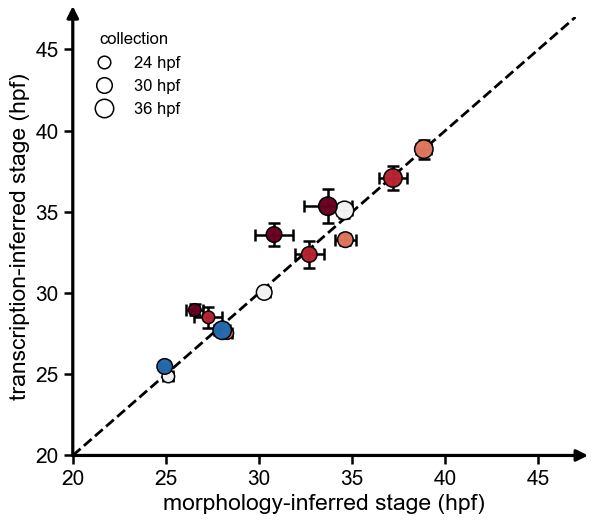

population mean groups plotted: 14
Saved /Users/nick/Projects/data/morphseq/results/20260528/sac_figs/01a_seq_vs_morph_stage_population_means_se_marker_size_by_collection_without_early_sac.png
Saved /Users/nick/Projects/data/morphseq/results/20260528/sac_figs/01a_seq_vs_morph_stage_population_means_se_marker_size_by_collection_without_early_sac.pdf


In [16]:
POP_MEAN_SIZE_BY_COLLECTION_INCLUDE_EARLY = False
POP_MEAN_SIZE_BY_COLLECTION_AXIS_LIMITS = (20, 47)
POP_MEAN_SIZE_BY_COLLECTION_POINT_SIZES = {24.0: 82, 30.0: 126, 36.0: 176}
POP_MEAN_SIZE_BY_COLLECTION_OUTPUT_STEM = '01a_seq_vs_morph_stage_population_means_se_marker_size_by_collection_without_early_sac'

pop_mean_size_data = stage_group_all.copy()
pop_mean_size_data['temperature'] = pop_mean_size_data['temperature'].astype(float)
pop_mean_size_data['timepoint'] = pop_mean_size_data['timepoint'].astype(float)
pop_mean_size_early_mask = (
    np.isclose(pop_mean_size_data['temperature'], 19.0)
    | (
        np.isclose(pop_mean_size_data['temperature'], 25.0)
        & np.isclose(pop_mean_size_data['timepoint'], 24.0)
    )
)
if not POP_MEAN_SIZE_BY_COLLECTION_INCLUDE_EARLY:
    pop_mean_size_data = pop_mean_size_data.loc[~pop_mean_size_early_mask].copy()

fig, ax = plt.subplots(figsize=(6.2, 5.5))
cmap = plt.get_cmap(TEMP_CMAP)
norm = temperature_norm()

ax.errorbar(
    pop_mean_size_data['morph_stage_mean_registered'],
    pop_mean_size_data['seq_stage_mean_registered'],
    xerr=pop_mean_size_data['morph_stage_mean_boot_se'],
    yerr=pop_mean_size_data['seq_stage_mean_boot_se'],
    fmt='none',
    ecolor='black',
    elinewidth=1.8,
    capsize=4,
    capthick=1.8,
    alpha=1,
    zorder=2,
)

for timepoint, group in pop_mean_size_data.groupby('timepoint', sort=True):
    ax.scatter(
        group['morph_stage_mean_registered'],
        group['seq_stage_mean_registered'],
        c=group['temperature'],
        cmap=cmap,
        norm=norm,
        marker='o',
        s=POP_MEAN_SIZE_BY_COLLECTION_POINT_SIZES.get(float(timepoint), 126),
        alpha=0.98,
        edgecolor='black',
        linewidth=1.1,
        zorder=3,
    )

ax.set_xlim(*POP_MEAN_SIZE_BY_COLLECTION_AXIS_LIMITS)
ax.set_ylim(*POP_MEAN_SIZE_BY_COLLECTION_AXIS_LIMITS)
add_identity(ax)
ax.set_xlabel('morphology-inferred stage (hpf)')
ax.set_ylabel('transcription-inferred stage (hpf)')
add_black_arrow_axes(ax)

legend_handles = []
for timepoint in sorted(pop_mean_size_data['timepoint'].unique()):
    legend_handles.append(
        Line2D(
            [0],
            [0],
            marker='o',
            linestyle='none',
            markerfacecolor='white',
            markeredgecolor='black',
            markeredgewidth=1.1,
            markersize=np.sqrt(POP_MEAN_SIZE_BY_COLLECTION_POINT_SIZES.get(float(timepoint), 126)),
            label=f'{float(timepoint):g} hpf',
        )
    )
legend = ax.legend(handles=legend_handles, title='collection', frameon=False, loc='best')
for text in [legend.get_title(), *legend.get_texts()]:
    text.set_color('black')

fig.tight_layout()
for suffix in ('png', 'pdf'):
    fig.savefig(OUT_DIR / f'{POP_MEAN_SIZE_BY_COLLECTION_OUTPUT_STEM}.{suffix}', dpi=300, bbox_inches='tight')
plt.show()

print(f'population mean groups plotted: {len(pop_mean_size_data)}')
print(f'Saved {OUT_DIR / f"{POP_MEAN_SIZE_BY_COLLECTION_OUTPUT_STEM}.png"}')
print(f'Saved {OUT_DIR / f"{POP_MEAN_SIZE_BY_COLLECTION_OUTPUT_STEM}.pdf"}')

In [ ]:
POP_MEAN_SIZE_BY_COLLECTION_INCLUDE_EARLY = False
POP_MEAN_SIZE_BY_COLLECTION_AXIS_LIMITS = (20, 47)
POP_MEAN_SIZE_BY_COLLECTION_POINT_SIZES = {24.0: 82, 30.0: 126, 36.0: 176}
POP_MEAN_SIZE_BY_COLLECTION_SD_OUTPUT_STEM = '01a_seq_vs_morph_stage_population_means_sd_marker_size_by_collection_without_early_sac'

pop_mean_size_sd_data = stage_group_all.copy()
pop_mean_size_sd_data['temperature'] = pop_mean_size_sd_data['temperature'].astype(float)
pop_mean_size_sd_data['timepoint'] = pop_mean_size_sd_data['timepoint'].astype(float)
pop_mean_size_sd_early_mask = (
    np.isclose(pop_mean_size_sd_data['temperature'], 19.0)
    | (
        np.isclose(pop_mean_size_sd_data['temperature'], 25.0)
        & np.isclose(pop_mean_size_sd_data['timepoint'], 24.0)
    )
)
if not POP_MEAN_SIZE_BY_COLLECTION_INCLUDE_EARLY:
    pop_mean_size_sd_data = pop_mean_size_sd_data.loc[~pop_mean_size_sd_early_mask].copy()

fig, ax = plt.subplots(figsize=(6.2, 5.5))
cmap = plt.get_cmap(TEMP_CMAP)
norm = temperature_norm()

ax.errorbar(
    pop_mean_size_sd_data['morph_stage_mean_registered'],
    pop_mean_size_sd_data['seq_stage_mean_registered'],
    xerr=pop_mean_size_sd_data['morph_stage_sd'],
    yerr=pop_mean_size_sd_data['seq_stage_sd'],
    fmt='none',
    ecolor='black',
    elinewidth=1.8,
    capsize=4,
    capthick=1.8,
    alpha=1,
    zorder=2,
)

for timepoint, group in pop_mean_size_sd_data.groupby('timepoint', sort=True):
    ax.scatter(
        group['morph_stage_mean_registered'],
        group['seq_stage_mean_registered'],
        c=group['temperature'],
        cmap=cmap,
        norm=norm,
        marker='o',
        s=POP_MEAN_SIZE_BY_COLLECTION_POINT_SIZES.get(float(timepoint), 126),
        alpha=0.98,
        edgecolor='black',
        linewidth=1.1,
        zorder=3,
    )

ax.set_xlim(*POP_MEAN_SIZE_BY_COLLECTION_AXIS_LIMITS)
ax.set_ylim(*POP_MEAN_SIZE_BY_COLLECTION_AXIS_LIMITS)
add_identity(ax)
ax.set_xlabel('morphology-inferred stage (hpf)')
ax.set_ylabel('transcription-inferred stage (hpf)')
add_black_arrow_axes(ax)

legend_handles = []
for timepoint in sorted(pop_mean_size_sd_data['timepoint'].unique()):
    legend_handles.append(
        Line2D(
            [0],
            [0],
            marker='o',
            linestyle='none',
            markerfacecolor='white',
            markeredgecolor='black',
            markeredgewidth=1.1,
            markersize=np.sqrt(POP_MEAN_SIZE_BY_COLLECTION_POINT_SIZES.get(float(timepoint), 126)),
            label=f'{float(timepoint):g} hpf',
        )
    )
legend = ax.legend(handles=legend_handles, title='collection', frameon=False, loc='best')
for text in [legend.get_title(), *legend.get_texts()]:
    text.set_color('black')

fig.tight_layout()
for suffix in ('png', 'pdf'):
    fig.savefig(OUT_DIR / f'{POP_MEAN_SIZE_BY_COLLECTION_SD_OUTPUT_STEM}.{suffix}', dpi=300, bbox_inches='tight')
plt.show()

print(f'population mean groups plotted: {len(pop_mean_size_sd_data)}')
print(f'Saved {OUT_DIR / f"{POP_MEAN_SIZE_BY_COLLECTION_SD_OUTPUT_STEM}.png"}')
print(f'Saved {OUT_DIR / f"{POP_MEAN_SIZE_BY_COLLECTION_SD_OUTPUT_STEM}.pdf"}')


In [ ]:
POP_MEAN_SIZE_BY_COLLECTION_INCLUDE_EARLY = False
POP_MEAN_SIZE_BY_COLLECTION_AXIS_LIMITS = (20, 47)
POP_MEAN_SIZE_BY_COLLECTION_POINT_SIZES = {24.0: 82, 30.0: 126, 36.0: 176}
POP_MEAN_SIZE_BY_COLLECTION_SD_NO_CAPS_OUTPUT_STEM = '01a_seq_vs_morph_stage_population_means_sd_marker_size_by_collection_without_early_sac_no_caps'

pop_mean_size_sd_data = stage_group_all.copy()
pop_mean_size_sd_data['temperature'] = pop_mean_size_sd_data['temperature'].astype(float)
pop_mean_size_sd_data['timepoint'] = pop_mean_size_sd_data['timepoint'].astype(float)
pop_mean_size_sd_early_mask = (
    np.isclose(pop_mean_size_sd_data['temperature'], 19.0)
    | (
        np.isclose(pop_mean_size_sd_data['temperature'], 25.0)
        & np.isclose(pop_mean_size_sd_data['timepoint'], 24.0)
    )
)
if not POP_MEAN_SIZE_BY_COLLECTION_INCLUDE_EARLY:
    pop_mean_size_sd_data = pop_mean_size_sd_data.loc[~pop_mean_size_sd_early_mask].copy()

fig, ax = plt.subplots(figsize=(6.2, 5.5))
cmap = plt.get_cmap(TEMP_CMAP)
norm = temperature_norm()

ax.errorbar(
    pop_mean_size_sd_data['morph_stage_mean_registered'],
    pop_mean_size_sd_data['seq_stage_mean_registered'],
    xerr=pop_mean_size_sd_data['morph_stage_sd'],
    yerr=pop_mean_size_sd_data['seq_stage_sd'],
    fmt='none',
    ecolor='black',
    elinewidth=1.8,
    capsize=0,
    capthick=0,
    alpha=1,
    zorder=2,
)

for timepoint, group in pop_mean_size_sd_data.groupby('timepoint', sort=True):
    ax.scatter(
        group['morph_stage_mean_registered'],
        group['seq_stage_mean_registered'],
        c=group['temperature'],
        cmap=cmap,
        norm=norm,
        marker='o',
        s=POP_MEAN_SIZE_BY_COLLECTION_POINT_SIZES.get(float(timepoint), 126),
        alpha=0.98,
        edgecolor='black',
        linewidth=1.1,
        zorder=3,
    )

ax.set_xlim(*POP_MEAN_SIZE_BY_COLLECTION_AXIS_LIMITS)
ax.set_ylim(*POP_MEAN_SIZE_BY_COLLECTION_AXIS_LIMITS)
add_identity(ax)
ax.set_xlabel('morphology-inferred stage (hpf)')
ax.set_ylabel('transcription-inferred stage (hpf)')
add_black_arrow_axes(ax)

legend_handles = []
for timepoint in sorted(pop_mean_size_sd_data['timepoint'].unique()):
    legend_handles.append(
        Line2D(
            [0],
            [0],
            marker='o',
            linestyle='none',
            markerfacecolor='white',
            markeredgecolor='black',
            markeredgewidth=1.1,
            markersize=np.sqrt(POP_MEAN_SIZE_BY_COLLECTION_POINT_SIZES.get(float(timepoint), 126)),
            label=f'{float(timepoint):g} hpf',
        )
    )
legend = ax.legend(handles=legend_handles, title='collection', frameon=False, loc='best')
for text in [legend.get_title(), *legend.get_texts()]:
    text.set_color('black')

fig.tight_layout()
for suffix in ('png', 'pdf'):
    fig.savefig(OUT_DIR / f'{POP_MEAN_SIZE_BY_COLLECTION_SD_NO_CAPS_OUTPUT_STEM}.{suffix}', dpi=300, bbox_inches='tight')
plt.show()

print(f'population mean groups plotted: {len(pop_mean_size_sd_data)}')
print(f'Saved {OUT_DIR / f"{POP_MEAN_SIZE_BY_COLLECTION_SD_NO_CAPS_OUTPUT_STEM}.png"}')
print(f'Saved {OUT_DIR / f"{POP_MEAN_SIZE_BY_COLLECTION_SD_NO_CAPS_OUTPUT_STEM}.pdf"}')
